#### AIT 736 Team 9 Final Project
<i> Charles Uttam P Ramanuja</i><br>
<i> Kartikey Avinash Kawadkar</i><br>
<i> Sai Praneetha Dasika</i><br>

#### Problem Framing

###### 1. Goal
The primary objective of this project is to accurately forecast the hourly bike demand and dock availability across individual Capital Bikeshare stations. By anticipating station depletion or overflow before it happens, operations teams can proactively dispatch rebalancing vans, thereby minimizing lost revenue and maximizing rider satisfaction.
#### 2. Target Variable
This is framed as a **Time-Series Regression** problem. The primary target variables being predicted are:
- **Demand**: A continuous integer representing the total number of bikes rented from a specific station within a given 1-hour window.
- **Dock Availability**: The reconstructed real-time count of available docks at that station.
#### 3. Unit of Analysis
The unit of analysis is the **Station-Hour**. Each row in our final modeled dataset represents the aggregated conditions and target outcome for a single physical station during a specific one-hour block (e.g., Station 31104 on April 15th, 08:00 AM - 09:00 AM).
#### 4. Assumptions
- **Behavioral Consistency:** We assume that historical commuter patterns, seasonal usage, and weekend tourist behavior are cyclical and will generalize to future dates.
- **Weather Dependency:** We assume weather conditions (temperature, precipitation) heavily dictate rider behavior and are accurately captured at the hourly level.
- **Static Infrastructure:** We assume that station locations and their maximum dock capacities remain largely constant during the prediction window, relying on the GBFS feed to establish baseline limits.
#### 5. Risk of Data Leakage and Mitigation
- **The Risk (Look-ahead Bias):** In time-series data, using standard random cross-validation (like train_test_split without shuffle=False) will cause data leakage. The model would "see" future events (e.g., Friday's demand) to predict past events (e.g., Thursday's demand). Furthermore, creating rolling averages improperly can accidentally include the target hour's data.
- **Mitigation:** 
    1. **Chronological Splitting:** We strictly partition the data by time (e.g., training on April through January, testing on February/March). 
    2. **Strict Lagging:** All temporal feature engineering (rolling means, lag features) utilizes strict shift() operations to ensure only strictly historical (t-1, t-2, etc.) data is used to predict state t.
#### 6. Evaluation Metric
To fairly evaluate our baseline (Decision Tree) and main models (Random Forest, CatBoost, LSTM), all final metrics are derived exclusively from predictions made on the unseen **Test Set**. We utilize two primary metrics:
- **RMSE (Root Mean Squared Error):** This is our primary optimization metric because it heavily penalizes large errors. In a bikeshare network, missing a prediction by 10 bikes (causing a completely empty station) is exponentially worse for operations than missing by 1 bike ten times.
- **MAE (Mean Absolute Error):** Used for human interpretability. It tells us, on average, exactly how many physical bikes our prediction is off by.

In [159]:
import os
import requests
import zipfile
import io

# 1. Setup the target directory (Creates it automatically if it doesn't exist)
target_dir = 'raw_trips'
os.makedirs(target_dir, exist_ok=True)

# 2. Define the exact months to download (April 2025 to March 2026)
# Generate lists for 2025 (months 04-12) and 2026 (months 01-03)
months_2025 = [f"2025{str(month).zfill(2)}" for month in range(4, 13)]
months_2026 = [f"2026{str(month).zfill(2)}" for month in range(1, 4)]
months_to_fetch = months_2025 + months_2026

# Capital Bikeshare S3 Bucket URL pattern
base_url = "https://s3.amazonaws.com/capitalbikeshare-data/{}-capitalbikeshare-tripdata.zip"

print(f"Creating '{target_dir}' folder and starting download for {len(months_to_fetch)} months")
print(f"Timeframe: {months_to_fetch[0]} to {months_to_fetch[-1]}")
print("-" * 50)

# 3. Loop through, download, and extract
for month in months_to_fetch:
    url = base_url.format(month)
    print(f"Fetching data for {month}")

    try:
        # Stream the download to handle large files better
        response = requests.get(url, timeout=30)

        if response.status_code == 200:
            # Unzip the content directly into the target directory
            with zipfile.ZipFile(io.BytesIO(response.content)) as z:
                z.extractall(target_dir)
            print(f"Successfully downloaded and extracted: {month}")
        else:
            print(f"Failed to download {month} (Status Code: {response.status_code})")

    except Exception as e:
        print(f"Error downloading {month}: {e}")

print("-" * 50)
print(f"Complete! All files saved to the '{target_dir}' folder.")

Creating 'raw_trips' folder and starting download for 12 months
Timeframe: 202504 to 202603
--------------------------------------------------
Fetching data for 202504
Successfully downloaded and extracted: 202504
Fetching data for 202505
Successfully downloaded and extracted: 202505
Fetching data for 202506
Successfully downloaded and extracted: 202506
Fetching data for 202507
Successfully downloaded and extracted: 202507
Fetching data for 202508
Successfully downloaded and extracted: 202508
Fetching data for 202509
Successfully downloaded and extracted: 202509
Fetching data for 202510
Successfully downloaded and extracted: 202510
Fetching data for 202511
Successfully downloaded and extracted: 202511
Fetching data for 202512
Successfully downloaded and extracted: 202512
Fetching data for 202601
Successfully downloaded and extracted: 202601
Fetching data for 202602
Successfully downloaded and extracted: 202602
Fetching data for 202603
Successfully downloaded and extracted: 202603
-----

In [160]:
import pandas as pd
import requests
import os

print("Fetching Raw GBFS Station Data")

# Capital Bikeshare GBFS station information endpoint
url = "https://gbfs.lyft.com/gbfs/2.3/dca-cabi/en/station_information.json"

print("Requesting live station data from Capital Bikeshare")
response = requests.get(url)

# Extract the stations list from the JSON payload
stations = response.json()['data']['stations']

# Convert to a Pandas DataFrame
df_stations_raw = pd.DataFrame(stations)

# Create the directory if it doesn't exist to maintain folder structure
os.makedirs('raw_gbfs', exist_ok=True)

# Save to CSV
df_stations_raw.to_csv('raw_gbfs/raw_stations.csv', index=False)

print(f"Success! Raw GBFS stations loaded: {len(df_stations_raw):,}")
print("Complete: Saved as 'raw_gbfs/raw_stations.csv'\n")

display(df_stations_raw.head())

Fetching Raw GBFS Station Data
Requesting live station data from Capital Bikeshare
Success! Raw GBFS stations loaded: 820
Complete: Saved as 'raw_gbfs/raw_stations.csv'



,short_name,capacity,lon,lat,station_id,region_id,rental_uris,name
0,31638,15,-77.012108,38.900358,0825e1e5-1f3f-11e7-bf6b-3863bb334450,42,{'android': 'https://dc.lft.to/lastmile_qr_sca...,1st & H St NW
1,31066,8,-77.072296,38.867217,082569e6-1f3f-11e7-bf6b-3863bb334450,41,{'android': 'https://dc.lft.to/lastmile_qr_sca...,Columbia Pike & S Orme St
2,31673,19,-77.020788,38.874821,94b1507c-7f76-483c-b06a-a4131e0b5970,42,{'android': 'https://dc.lft.to/lastmile_qr_sca...,Waterfront Park
3,31045,15,-77.052925,38.805630,08253b95-1f3f-11e7-bf6b-3863bb334450,40,{'android': 'https://dc.lft.to/lastmile_qr_sca...,Commerce St & Fayette St
4,31140,16,-77.046567,38.904052,2061578790793374684,42,{'android': 'https://dc.lft.to/lastmile_qr_sca...,21st & L St NW


In [161]:
import pandas as pd
import requests
import os

print("Fetching Raw Historical Weather Data")

# Washington D.C. coordinates and your project timeframe
lat, lon = 38.9072, -77.0369
start_date, end_date = "2025-04-01", "2026-03-31"

# Constructing the Open-Meteo API URL
url = (f"https://archive-api.open-meteo.com/v1/archive?"
       f"latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}"
       f"&hourly=temperature_2m,relative_humidity_2m,precipitation,snowfall,wind_speed_10m"
       f"&timezone=America/New_York")

print(f"Requesting hourly weather data from {start_date} to {end_date}")
response = requests.get(url)

# Extract the hourly data from the JSON payload
hourly_data = response.json()['hourly']

# Convert to a Pandas DataFrame
df_weather_raw = pd.DataFrame(hourly_data)

# Create the directory
os.makedirs('raw_weather', exist_ok=True)

# Save to CSV
df_weather_raw.to_csv('raw_weather/raw_weather.csv', index=False)

print(f"Success! Raw weather hours loaded: {len(df_weather_raw):,}")
print("Complete: Saved as 'raw_weather/raw_weather.csv'\n")

display(df_weather_raw.head())

Fetching Raw Historical Weather Data
Requesting hourly weather data from 2025-04-01 to 2026-03-31
Success! Raw weather hours loaded: 8,760
Complete: Saved as 'raw_weather/raw_weather.csv'



,time,temperature_2m,relative_humidity_2m,precipitation,snowfall,wind_speed_10m
0,2025-04-01T00:00,16.1,92,0.6,0.0,22.7
1,2025-04-01T01:00,12.9,86,0.5,0.0,26.8
2,2025-04-01T02:00,10.8,77,0.1,0.0,25.4
3,2025-04-01T03:00,9.4,67,0.0,0.0,26.0
4,2025-04-01T04:00,8.1,62,0.0,0.0,24.7


In [162]:
import pandas as pd
import os

print("Cleaning GBFS Station Data")

# 1. Load the raw station data
print("Loading raw GBFS data")
df_stations = pd.read_csv('raw_gbfs/raw_stations.csv')

# 2. Format the ID to be a clean string to prevent merge failures
df_stations['station_id'] = df_stations['short_name'].astype(str).str.strip()

# 3. Filter columns, drop missing values, and remove duplicates
# We dropna only on the critical columns to ensure we don't lose a station just because it's missing a minor detail
df_stations = df_stations[['station_id', 'name', 'lat', 'lon', 'capacity']].dropna(
    subset=['station_id', 'lat', 'lon', 'capacity']
).drop_duplicates(subset=['station_id'])

#3b. Convert capacity to a Nullable Integer type
df_stations['capacity'] = df_stations['capacity'].astype('Int64')

# 4. Save to the processed layer
os.makedirs('processed', exist_ok=True)
df_stations.to_parquet('processed/cleaned_gbfs.parquet')

print(f"GBFS cleaned: Final  station count: {len(df_stations):,}")
print("Complete: Saved as 'processed/cleaned_gbfs.parquet'\n")

display(df_stations.head())

Cleaning GBFS Station Data
Loading raw GBFS data
GBFS cleaned: Final  station count: 820
Complete: Saved as 'processed/cleaned_gbfs.parquet'



,station_id,name,lat,lon,capacity
0,31638,1st & H St NW,38.900358,-77.012108,15
1,31066,Columbia Pike & S Orme St,38.867217,-77.072296,8
2,31673,Waterfront Park,38.874821,-77.020788,19
3,31045,Commerce St & Fayette St,38.805630,-77.052925,15
4,31140,21st & L St NW,38.904052,-77.046567,16


In [163]:
import pandas as pd
import os

print("Cleaning Weather Data")

# 1. Load the raw weather data
print("Loading raw historical weather data")
df_weather = pd.read_csv('raw_weather/raw_weather.csv')

# 2. Convert 'time' from a string to a proper Datetime object
df_weather['time'] = pd.to_datetime(df_weather['time'])

# 3. Clean up: Remove duplicate hours and forward-fill any missing data
df_weather = df_weather.drop_duplicates(subset=['time']).ffill().dropna()

# 4. Save to the processed layer
os.makedirs('processed', exist_ok=True)
df_weather.to_parquet('processed/cleaned_weather.parquet')

print(f"Weather cleaned: Final hourly records: {len(df_weather):,}")
print("Complete: Saved as 'processed/cleaned_weather.parquet'\n")

display(df_weather.head())

Cleaning Weather Data
Loading raw historical weather data
Weather cleaned: Final hourly records: 8,760
Complete: Saved as 'processed/cleaned_weather.parquet'



,time,temperature_2m,relative_humidity_2m,precipitation,snowfall,wind_speed_10m
0,2025-04-01 00:00:00,16.1,92,0.6,0.0,22.7
1,2025-04-01 01:00:00,12.9,86,0.5,0.0,26.8
2,2025-04-01 02:00:00,10.8,77,0.1,0.0,25.4
3,2025-04-01 03:00:00,9.4,67,0.0,0.0,26.0
4,2025-04-01 04:00:00,8.1,62,0.0,0.0,24.7


In [164]:
import pandas as pd
import os
import glob
import warnings

# Suppress minor Pandas future warnings to keep the output clean
warnings.filterwarnings('ignore', category=FutureWarning)

print("Cleaning Trips Data ")

# 1. Load the raw trips data (12 months of CSVs)
print("Loading 12 months of trip CSV files")
path = r'raw_trips' # Ensure 12 raw CSVs are in this folder
all_files = glob.glob(os.path.join(path, "*.csv"))

if not all_files:
    print(" No CSV files found in 'raw_trips/'. Please check your folder path.")
else:
    # Concatenate all CSVs into one DataFrame
    df_trips = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
    print(f"Initial raw trips loaded: {len(df_trips):,}")

    # 2. Drop rows missing essential IDs
    df_trips = df_trips.dropna(subset=['start_station_id', 'end_station_id'])

    # 3. Handle Datetimes and Drop Short Trips (< 60 seconds)
    df_trips['started_at'] = pd.to_datetime(df_trips['started_at'])
    df_trips['ended_at'] = pd.to_datetime(df_trips['ended_at'])
    df_trips['duration_seconds'] = (df_trips['ended_at'] - df_trips['started_at']).dt.total_seconds()

    # Filter out false starts
    df_trips = df_trips[df_trips['duration_seconds'] >= 60]

    # 4. Create the hourly alignment column for Weather matching
    df_trips['hour_started'] = df_trips['started_at'].dt.round('h')

    # 5. Drop noisy GPS coordinates (we get these exact coordinates from GBFS later)
    cols_to_drop = ['start_station_name', 'end_station_name', 'start_lat', 'start_lng', 'end_lat', 'end_lng']
    df_trips = df_trips.drop(columns=[col for col in cols_to_drop if col in df_trips.columns], errors='ignore')

    # 6. Standardize IDs to clean strings, stripping any float decimals
    df_trips['start_station_id'] = df_trips['start_station_id'].astype(str).str.replace(r'\.0', '', regex=True)
    df_trips['end_station_id'] = df_trips['end_station_id'].astype(str).str.replace(r'\.0', '', regex=True)

    # 7. Save to the processed
    os.makedirs('processed', exist_ok=True)
    df_trips.to_parquet('processed/cleaned_trips.parquet')

    print(f"Trips cleaned: Final count: {len(df_trips):,}")
    print("Complete: Saved as 'processed/cleaned_trips.parquet'\n")

    display(df_trips.head())

Cleaning Trips Data 
Loading 12 months of trip CSV files
Initial raw trips loaded: 6,380,213
Trips cleaned: Final count: 4,460,990
Complete: Saved as 'processed/cleaned_trips.parquet'



,ride_id,rideable_type,started_at,ended_at,start_station_id,end_station_id,member_casual,duration_seconds,hour_started
945,65E1567809B66ABD,classic_bike,2025-04-15 08:57:34.113,2025-04-15 09:31:14.525,31672,31672,member,2020.412,2025-04-15 09:00:00
2724,53477DE9CD38C808,classic_bike,2025-04-27 09:23:37.011,2025-04-27 11:09:24.956,32433,32433,casual,6347.945,2025-04-27 09:00:00
5246,C775F12146879788,classic_bike,2025-04-23 21:51:22.808,2025-04-23 21:52:57.004,31672,31672,casual,94.196,2025-04-23 22:00:00
9751,81DD731575887265,electric_bike,2025-04-12 08:27:25.081,2025-04-12 08:47:41.533,31119,31302,member,1216.452,2025-04-12 08:00:00
9752,13D08713F5D2A9DF,classic_bike,2025-04-12 11:53:13.281,2025-04-12 12:12:35.883,31302,31119,member,1162.602,2025-04-12 12:00:00


#### Dataset and Variables Overview
Following the automated ingestion and cleaning phases, our master dataset is constructed from three distinct sources (GBFS, Weather, and Trips). 

**Key Variables Retained:**
* **Temporal:** started_at, ended_at (used to reconstruct hourly windows).
* **Spatial/Infrastructure:** station_id, capacity (defines the physical constraints of our network).
* **Environmental:** temperature, precipitation, wind_speed (key external drivers of demand).

**Excluded Data & Reasoning:**
* **Missing Station IDs:** Trips missing a start or end station were dropped. These usually represent bikes taken out by maintenance crews and do not reflect consumer demand.
* **Duration Anomalies (< 1 min or > 24 hours):** Trips under one minute are almost exclusively "false starts" (a user unlocks a bike and immediately returns it due to a defect). Trips over 24 hours often indicate lost, stolen, or improperly docked bikes. Retaining these would introduce severe noise into our hourly demand calculations.

#### Data Integration (Spatial & Temporal Joins)
With our three raw datasets thoroughly cleaned and formatted, the next step is to unify them into a single, cohesive pipeline. 

Because bikeshare demand is dictated by both *where* a station is and *what* the environment is like, we execute two critical merges:
1. **The Spatial Join (Trips + GBFS):** We map the physical location (Lat/Lon) and maximum physical dock capacity to our historical trip data using the station_id as the primary key.
2. **The Temporal Join (Trips + Weather):** We attach the specific environmental reality (temperature, precipitation, wind) to our aggregated hourly trips using the synchronized date_hour floor as the primary key.

In [165]:
import pandas as pd
import os

print("Spatial Join (Stations)")

# 1. Load the datasets
print("Loading cleaned trips and station data")
df_trips = pd.read_parquet('processed/cleaned_trips.parquet')
df_stations = pd.read_parquet('processed/cleaned_gbfs.parquet')

print("Executing Spatial Joins")

# 2. Join 1: Attach Start Station details (ONLY name and capacity)
df_spatial = df_trips.merge(
    df_stations[['station_id', 'name', 'capacity']],
    left_on='start_station_id',
    right_on='station_id',
    how='left'
)

# Rename the newly attached columns
df_spatial = df_spatial.rename(columns={
    'name': 'start_station_name',
    'capacity': 'start_capacity'
}).drop(columns=['station_id'])

# 3. Join 2: Attach End Station details (ONLY name and capacity)
df_spatial = df_spatial.merge(
    df_stations[['station_id', 'name', 'capacity']],
    left_on='end_station_id',
    right_on='station_id',
    how='left'
)

# Rename the newly attached columns
df_spatial = df_spatial.rename(columns={
    'name': 'end_station_name',
    'capacity': 'end_capacity'
}).drop(columns=['station_id'])

# 4. Save the intermediate spatial dataset
os.makedirs('processed', exist_ok=True)
df_spatial.to_parquet('processed/spatial_joined_trips.parquet')

print(f"Spatial Join Complete! Dataset Shape: {df_spatial.shape}")
print("Complete: Saved as 'processed/spatial_joined_trips.parquet'\n")

display(df_spatial.head())

# Validation
missing_start_cap = df_spatial['start_capacity'].isna().sum()
print(f"Validation: Trips missing start capacity after merge: {missing_start_cap:,} out of {len(df_spatial):,}")

missing_end_cap = df_spatial['end_capacity'].isna().sum()
print(f"Validation: Trips missing ending capacity after merge: {missing_end_cap:,} out of {len(df_spatial):,}")

Spatial Join (Stations)
Loading cleaned trips and station data
Executing Spatial Joins
Spatial Join Complete! Dataset Shape: (4460990, 13)
Complete: Saved as 'processed/spatial_joined_trips.parquet'



,ride_id,rideable_type,started_at,ended_at,start_station_id,end_station_id,member_casual,duration_seconds,hour_started,start_station_name,start_capacity,end_station_name,end_capacity
0,65E1567809B66ABD,classic_bike,2025-04-15 08:57:34.113,2025-04-15 09:31:14.525,31672,31672,member,2020.412,2025-04-15 09:00:00,10th & H St NE,19,10th & H St NE,19
1,53477DE9CD38C808,classic_bike,2025-04-27 09:23:37.011,2025-04-27 11:09:24.956,32433,32433,casual,6347.945,2025-04-27 09:00:00,Rhode Island Avenue /Charles Armentrout Drive ...,15,Rhode Island Avenue /Charles Armentrout Drive ...,15
2,C775F12146879788,classic_bike,2025-04-23 21:51:22.808,2025-04-23 21:52:57.004,31672,31672,casual,94.196,2025-04-23 22:00:00,10th & H St NE,19,10th & H St NE,19
3,81DD731575887265,electric_bike,2025-04-12 08:27:25.081,2025-04-12 08:47:41.533,31119,31302,member,1216.452,2025-04-12 08:00:00,14th & Belmont St NW,24,Wisconsin Ave & Newark St NW,19
4,13D08713F5D2A9DF,classic_bike,2025-04-12 11:53:13.281,2025-04-12 12:12:35.883,31302,31119,member,1162.602,2025-04-12 12:00:00,Wisconsin Ave & Newark St NW,19,14th & Belmont St NW,24


Validation: Trips missing start capacity after merge: 17,143 out of 4,460,990
Validation: Trips missing ending capacity after merge: 17,164 out of 4,460,990


In [166]:
import pandas as pd

print("Investigating Missing Station Capacities")

# 1. Load the spatial dataset we just created
df_spatial = pd.read_parquet('processed/spatial_joined_trips.parquet')
initial_len = len(df_spatial)

# 2. Filter for rows where EITHER the start capacity OR the end capacity is missing
df_missing = df_spatial[df_spatial['start_capacity'].isna() | df_spatial['end_capacity'].isna()]

print(f"Total trips with missing station data: {len(df_missing):,}")

# 3. Let's look at what specific station IDs are missing!
display(df_missing.head(5))

print("Dropping Missing Station Rows")

# 4. Drop the rows missing start or end capacities
df_spatial = df_spatial.dropna(subset=['start_capacity', 'end_capacity'])
final_len = len(df_spatial)

print(f"Initial trip count: {initial_len:,}")
print(f"Trips dropped: {initial_len - final_len:,}")
print(f"Cleaned trip count: {final_len:,}")

# 5. Overwrite the spatial dataset so the clean version is locked in
df_spatial.to_parquet('processed/spatial_joined_trips.parquet')

print("\nComplete: Missing station rows dropped and spatial dataset updated.")

Investigating Missing Station Capacities
Total trips with missing station data: 33,854


,ride_id,rideable_type,started_at,ended_at,start_station_id,end_station_id,member_casual,duration_seconds,hour_started,start_station_name,start_capacity,end_station_name,end_capacity
679,DB096D5C9AB3FD2C,classic_bike,2025-04-05 00:41:22.212,2025-04-05 00:48:40.880,31540,31642,member,438.668,2025-04-05 01:00:00,3rd & N St NE,11,NaN,<NA>
682,C0BC9DB88BEE7144,electric_bike,2025-04-12 14:28:13.409,2025-04-12 14:34:44.647,31624,31642,member,391.238,2025-04-12 14:00:00,North Capitol St & F St NW,23,NaN,<NA>
858,A7151FF5D1BEC947,electric_bike,2025-04-22 16:17:17.067,2025-04-22 16:31:17.311,31642,31419,member,840.244,2025-04-22 16:00:00,NaN,<NA>,Georgia Ave & Morton St NW,19
863,F45AEEB2D7C4EC1A,electric_bike,2025-04-18 16:25:17.206,2025-04-18 16:34:07.002,31642,31134,casual,529.796,2025-04-18 16:00:00,NaN,<NA>,8th & V St NW,19
1015,A8E09C3E7A23686F,classic_bike,2025-04-01 08:16:20.120,2025-04-01 08:18:42.847,31214,31200,member,142.727,2025-04-01 08:00:00,17th & Corcoran St NW,19,NaN,<NA>


Dropping Missing Station Rows
Initial trip count: 4,460,990
Trips dropped: 33,854
Cleaned trip count: 4,427,136

Complete: Missing station rows dropped and spatial dataset updated.


In [167]:
print("The length of total rows is: ",len(df_spatial))

print(df_spatial.isna().sum())

df_spatial.head()

The length of total rows is:  4427136
ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_id      0
end_station_id        0
member_casual         0
duration_seconds      0
hour_started          0
start_station_name    0
start_capacity        0
end_station_name      0
end_capacity          0
dtype: int64


,ride_id,rideable_type,started_at,ended_at,start_station_id,end_station_id,member_casual,duration_seconds,hour_started,start_station_name,start_capacity,end_station_name,end_capacity
0,65E1567809B66ABD,classic_bike,2025-04-15 08:57:34.113,2025-04-15 09:31:14.525,31672,31672,member,2020.412,2025-04-15 09:00:00,10th & H St NE,19,10th & H St NE,19
1,53477DE9CD38C808,classic_bike,2025-04-27 09:23:37.011,2025-04-27 11:09:24.956,32433,32433,casual,6347.945,2025-04-27 09:00:00,Rhode Island Avenue /Charles Armentrout Drive ...,15,Rhode Island Avenue /Charles Armentrout Drive ...,15
2,C775F12146879788,classic_bike,2025-04-23 21:51:22.808,2025-04-23 21:52:57.004,31672,31672,casual,94.196,2025-04-23 22:00:00,10th & H St NE,19,10th & H St NE,19
3,81DD731575887265,electric_bike,2025-04-12 08:27:25.081,2025-04-12 08:47:41.533,31119,31302,member,1216.452,2025-04-12 08:00:00,14th & Belmont St NW,24,Wisconsin Ave & Newark St NW,19
4,13D08713F5D2A9DF,classic_bike,2025-04-12 11:53:13.281,2025-04-12 12:12:35.883,31302,31119,member,1162.602,2025-04-12 12:00:00,Wisconsin Ave & Newark St NW,19,14th & Belmont St NW,24


In [168]:
import pandas as pd
import os

print("Temporal Join (Weather)")

# 1. Load the completely cleaned Spatial dataset and the Weather dataset
print("Loading spatial trips and weather data")
df_spatial = pd.read_parquet('processed/spatial_joined_trips.parquet')
df_weather = pd.read_parquet('processed/cleaned_weather.parquet')

# 2. Safety Check: Ensure both matching columns are timezone-naive datetimes
# This prevents merge errors if one dataset thinks it's in UTC and the other is local
df_spatial['hour_started'] = pd.to_datetime(df_spatial['hour_started']).dt.tz_localize(None)
df_weather['time'] = pd.to_datetime(df_weather['time']).dt.tz_localize(None)

print("Executing Temporal Join")

# 3. Join the Weather data
# We use a left join to ensure we don't drop any of our cleaned trips
df_final = df_spatial.merge(df_weather, left_on='hour_started', right_on='time', how='left')

# 4. Cleanup: Drop the redundant 'time' column from the weather dataset
df_final = df_final.drop(columns=['time'])

# 5. Save the final dataset
os.makedirs('processed', exist_ok=True)
df_final.to_parquet('processed/master_joined_data.parquet')

print(f"\nMerge Complete! Final Master Dataset Shape: {df_final.shape}")
print("Complete: Saved as 'processed/master_joined_data.parquet'\n")

df_final.head(5)

Temporal Join (Weather)
Loading spatial trips and weather data
Executing Temporal Join

Merge Complete! Final Master Dataset Shape: (4427136, 18)
Complete: Saved as 'processed/master_joined_data.parquet'



,ride_id,rideable_type,started_at,ended_at,start_station_id,end_station_id,member_casual,duration_seconds,hour_started,start_station_name,start_capacity,end_station_name,end_capacity,temperature_2m,relative_humidity_2m,precipitation,snowfall,wind_speed_10m
0,65E1567809B66ABD,classic_bike,2025-04-15 08:57:34.113,2025-04-15 09:31:14.525,31672,31672,member,2020.412,2025-04-15 09:00:00,10th & H St NE,19,10th & H St NE,19,16.6,82.0,0.1,0.0,8.7
1,53477DE9CD38C808,classic_bike,2025-04-27 09:23:37.011,2025-04-27 11:09:24.956,32433,32433,casual,6347.945,2025-04-27 09:00:00,Rhode Island Avenue /Charles Armentrout Drive ...,15,Rhode Island Avenue /Charles Armentrout Drive ...,15,11.1,53.0,0.0,0.0,24.0
2,C775F12146879788,classic_bike,2025-04-23 21:51:22.808,2025-04-23 21:52:57.004,31672,31672,casual,94.196,2025-04-23 22:00:00,10th & H St NE,19,10th & H St NE,19,18.2,44.0,0.0,0.0,7.6
3,81DD731575887265,electric_bike,2025-04-12 08:27:25.081,2025-04-12 08:47:41.533,31119,31302,member,1216.452,2025-04-12 08:00:00,14th & Belmont St NW,24,Wisconsin Ave & Newark St NW,19,6.0,91.0,0.1,0.0,13.5
4,13D08713F5D2A9DF,classic_bike,2025-04-12 11:53:13.281,2025-04-12 12:12:35.883,31302,31119,member,1162.602,2025-04-12 12:00:00,Wisconsin Ave & Newark St NW,19,14th & Belmont St NW,24,9.1,71.0,0.1,0.0,18.4


In [169]:
print("Investigating Missing Weather Rows")

# Filter the final dataframe for rows where the temperature is missing
df_missing_weather = df_final[df_final['temperature_2m'].isna()]

df_missing_weather.head()

print("Finalizing Master Dataset")

# Drop the out-of-scope bleed-over trips from March 31st
df_final = df_final.dropna(subset=['temperature_2m'])

# Overwrite the saved files with the perfectly clean dataset
df_final.to_parquet('processed/master_joined_data.parquet')
df_final.to_csv('processed/master_joined_data.csv', index=False)

print(df_final.isna().sum())

print(f"Cleaned! Final row count: {len(df_final):,}")

Investigating Missing Weather Rows
Finalizing Master Dataset
ride_id                 0
rideable_type           0
started_at              0
ended_at                0
start_station_id        0
end_station_id          0
member_casual           0
duration_seconds        0
hour_started            0
start_station_name      0
start_capacity          0
end_station_name        0
end_capacity            0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
snowfall                0
wind_speed_10m          0
dtype: int64
Cleaned! Final row count: 4,427,088


In [170]:
import pandas as pd
import numpy as np

print("Reconstruct Dock Availability")

# 1. Load the dataset
print("Loading master joined data")
df_final = pd.read_parquet('processed/master_joined_data.parquet')

# 2. Isolate Rentals (Start of a trip)
# When a bike is rented, a dock BECOMES AVAILABLE (+1)
df_rentals = pd.DataFrame({
    'ride_id': df_final['ride_id'],
    'station_id': df_final['start_station_id'],
    'station_name': df_final['start_station_name'],
    'event_time': df_final['started_at'],
    'event_type': 'rental',
    'dock_change': 1,
    'capacity': df_final['start_capacity']
})

# 3. Isolate Returns (End of a trip)
# When a bike is returned, a dock is TAKEN (-1)
df_returns = pd.DataFrame({
    'ride_id': df_final['ride_id'],
    'station_id': df_final['end_station_id'],
    'station_name': df_final['end_station_name'],
    'event_time': df_final['ended_at'],
    'event_type': 'return',
    'dock_change': -1,
    'capacity': df_final['end_capacity']
})

# 4. Combine and Chronologically Sort all 8.8 million events
print("Combining and sorting 8.8 million chronological events.")
df_events = pd.concat([df_rentals, df_returns], ignore_index=True)

# We sort by station_id first, then exactly by event_time to rebuild the physical timeline
df_events = df_events.sort_values(by=['station_id', 'event_time']).reset_index(drop=True)

# 5. The Bounded State Machine (Vectorized via NumPy arrays for massive speedup)
print("Calculating the bounded running tally per station.")

# Extract Pandas columns to raw NumPy arrays.
# Bypassing Pandas overhead makes this loop execute in seconds instead of hours.
station_ids = df_events['station_id'].values
dock_changes = df_events['dock_change'].values
capacities = df_events['capacity'].values

# Pre-allocate an empty array for the final results
available_docks_history = np.zeros(len(df_events), dtype=np.float32)
#available_docks_history = np.zeros(len(df_events), dtype=np.int32)

# Dictionary to hold the current state of each station in memory
current_docks = {}

for i in range(len(df_events)):
    station = station_ids[i]
    change = dock_changes[i]
    cap = capacities[i]

    # Initialize the station at 50% capacity if it's the first time we see it on the timeline
    if station not in current_docks:
        current_docks[station] = cap // 2

    # Apply the transactional change (rental = +1 available dock, return = -1 available dock)
    new_dock_count = current_docks[station] + change

    # Strictly bound the current state before moving to the next hour.
    # This acts as a self-correcting mechanism for Phantom Van Rebalancing.
    if new_dock_count > cap:
        new_dock_count = cap
    elif new_dock_count < 0:
        new_dock_count = 0

    # Save the bounded state back to memory and record it in the history array
    current_docks[station] = new_dock_count
    available_docks_history[i] = new_dock_count

# Attach the mathematically sound target variable back to the dataframe
df_events['available_docks'] = available_docks_history

print("\nComplete! Bounded chronological running tally generated.")

# Display a slice of a single station's timeline so we can visually verify the bounds are holding
sample_station = df_events['station_id'].iloc[0]
print(f"\nVisual Verification for Station ID: {sample_station}")
display(df_events[df_events['station_id'] == sample_station].head(15))

# Validate output
import os
os.makedirs('processed', exist_ok=True)
df_events.to_parquet('processed/validated_dock_tally.parquet')
print("Saved as 'processed/validated_dock_tally.parquet'")

Reconstruct Dock Availability
Loading master joined data
Combining and sorting 8.8 million chronological events.
Calculating the bounded running tally per station.

Complete! Bounded chronological running tally generated.

Visual Verification for Station ID: 30200


,ride_id,station_id,station_name,event_time,event_type,dock_change,capacity,available_docks
0,949B7BA56519045E,30200,9th St & Pennsylvania Ave NW,2025-04-01 05:23:59.209,return,-1,27,12.0
1,F8F7FE5D3E869DC8,30200,9th St & Pennsylvania Ave NW,2025-04-01 06:31:48.409,return,-1,27,11.0
2,A77C8854DD82EDAA,30200,9th St & Pennsylvania Ave NW,2025-04-01 06:52:52.052,rental,1,27,12.0
3,E9B5F91131B34425,30200,9th St & Pennsylvania Ave NW,2025-04-01 06:53:14.469,rental,1,27,13.0
4,275009114D2E6B32,30200,9th St & Pennsylvania Ave NW,2025-04-01 06:57:04.433,return,-1,27,12.0
5,4DB4B64774C5FDAE,30200,9th St & Pennsylvania Ave NW,2025-04-01 08:01:03.399,rental,1,27,13.0
6,80611FF251A6743E,30200,9th St & Pennsylvania Ave NW,2025-04-01 08:06:39.254,rental,1,27,14.0
7,9A84D2FE434C7511,30200,9th St & Pennsylvania Ave NW,2025-04-01 08:10:56.853,return,-1,27,13.0
8,A7C663E26AFDE49D,30200,9th St & Pennsylvania Ave NW,2025-04-01 08:23:46.761,return,-1,27,12.0
9,220DA4B7C7E106B0,30200,9th St & Pennsylvania Ave NW,2025-04-01 08:23:50.053,return,-1,27,11.0


Saved as 'processed/validated_dock_tally.parquet'


### Target Variable Reconstruction: Available Docks
A major challenge in this dataset is that while the live GBFS API provides the **static capacity** of each station (e.g., a station has 25 total physical docks), it does not provide historical logs of how many docks were actually available at a given time last year.

To solve this, we had to mathematically reconstruct the available_docks for every station at every hour using our trip data:
1. **Demand (Check-outs):** We counted how many trips *started* at the station during that hour.
2. **Returns (Check-ins):** We counted how many trips *ended* at the station during that hour.
3. **Net Flow Calculation:** We calculated the hourly net change in bikes (Returns - Demand).
4. **Chronological Simulation:** Starting from the known GBFS capacity, we applied a cumulative sum of the net flow chronologically to simulate the exact number of available_docks at the end of each hour. 

This transformation converts raw timestamps into a continuous, targetable state variable for our regression models.

Calculating KMeans for K=2 through 20.


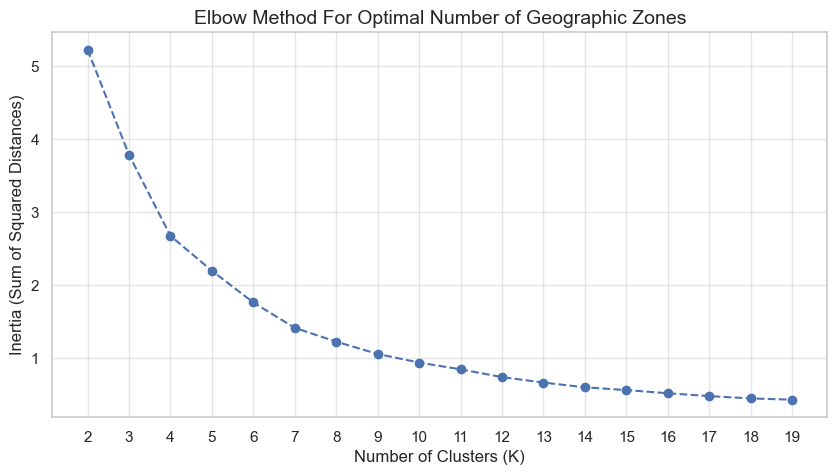

In [171]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', module='sklearn')

# 1. Load Data
df_stations = pd.read_parquet('processed/cleaned_gbfs.parquet')
coords = df_stations[['lat', 'lon']]

# 2. Calculate Inertia for the Elbow Plot
K_range = range(2, 20)
inertia = []

print("Calculating KMeans for K=2 through 20.")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords)
    inertia.append(km.inertia_)

# 3. Generate the Elbow Plot
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal Number of Geographic Zones', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, alpha=0.5)
plt.show()


### Geographic Dimensionality Reduction (K-Means Clustering)
The Capital Bikeshare network consists of over 800 unique physical stations. Passing 800 distinct categorical IDs into tree-based machine learning models can lead to high dimensionality, sparsity, and severe overfitting.

To solve this, we applied **K-Means Spatial Clustering** to the station coordinates (Latitude and Longitude). 
* **The Goal:** Group individual stations into larger behavioral regions (e.g., Downtown Business District, Suburban Residential, National Mall Tourist Hub). 
* **The Method:** We utilize the "Elbow Method" to calculate the Within-Cluster Sum of Squares (WCSS) across various values of $K$ to find the mathematically optimal number of geographic zones.
By engineering this geo_cluster feature, our models can learn broad, generalizable regional behaviors rather than trying to memorize the quirks of 800 individual docks.

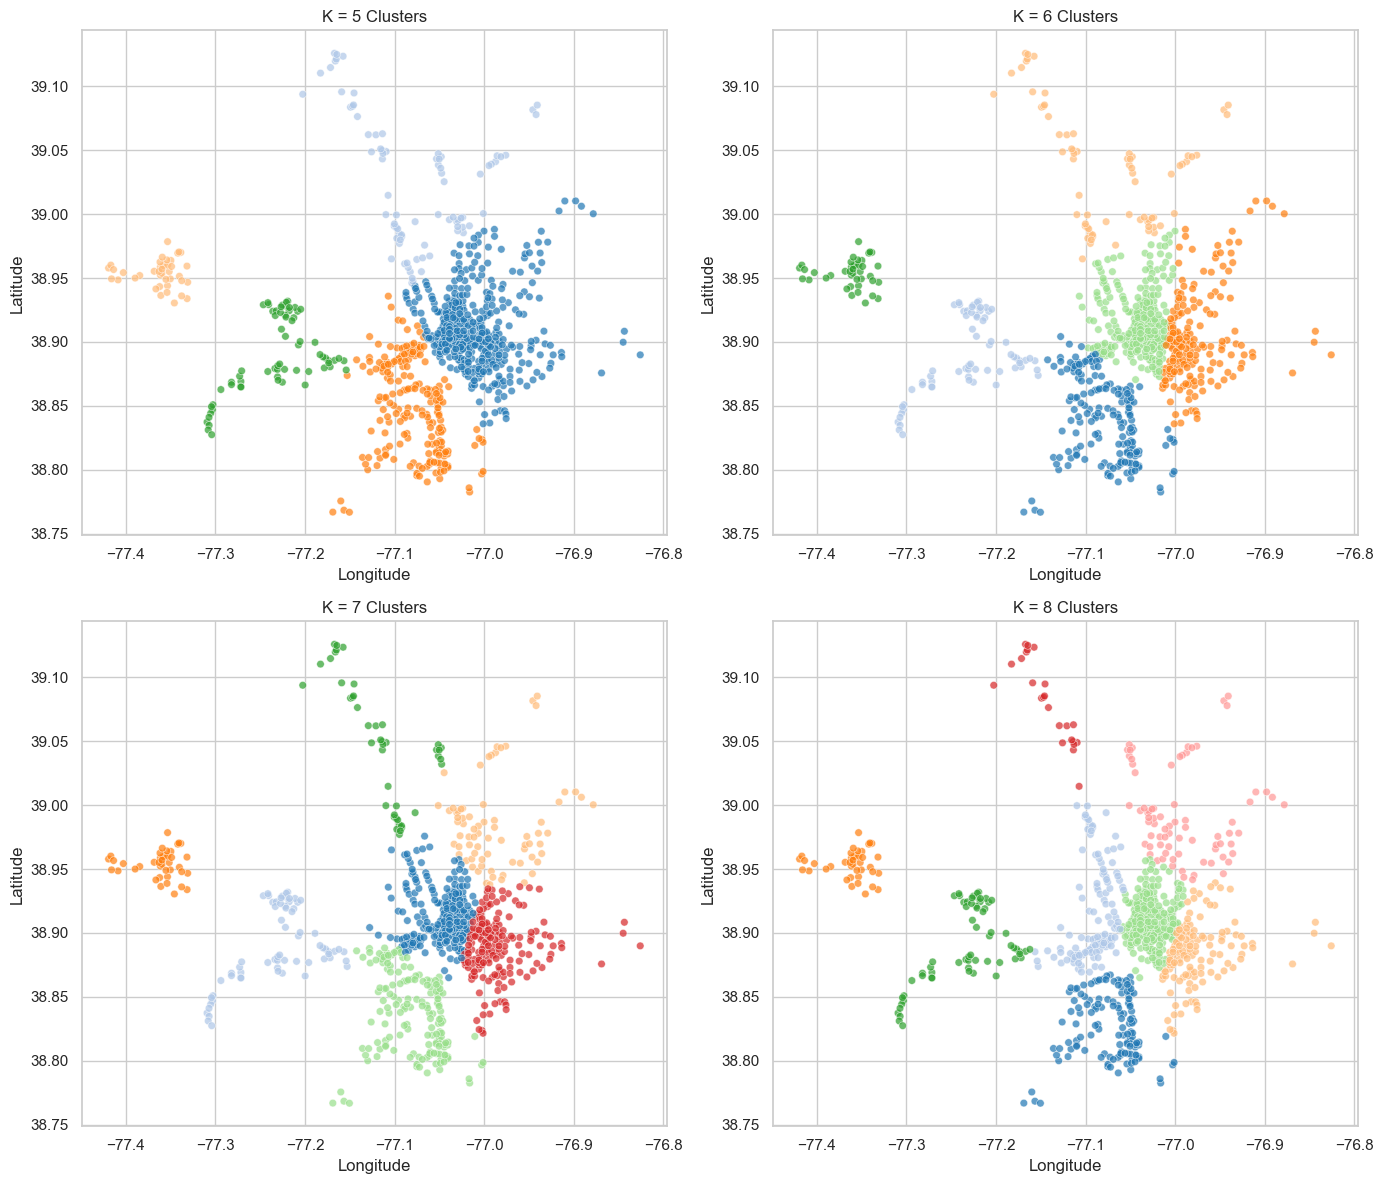

In [172]:
# Visual Comparison of optimal K values based on elbow method
compare_ks = [5, 6, 7, 8]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, k in enumerate(compare_ks):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(coords)

    sns.scatterplot(
        x=df_stations['lon'],
        y=df_stations['lat'],
        hue=cluster_labels,
        palette='tab20',
        ax=axes[i],
        s=30,
        alpha=0.7,
        legend=False
    )
    axes[i].set_title(f'K = {k} Clusters')
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

In [173]:
import pandas as pd
from sklearn.cluster import KMeans
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress minor sklearn memory leak warnings on Windows/Mac
warnings.filterwarnings('ignore', module='sklearn')

print("Geographic Clustering (K-Means)")

# 1. Load the  station locations
print("Loading physical station coordinates")
df_stations = pd.read_parquet('processed/cleaned_gbfs.parquet')

# Isolate the spatial features for the algorithm
coords = df_stations[['lat', 'lon']]

# 2. Configure and run K-Means
n_clusters = 8
print(f"Applying K-Means to group stations into {n_clusters} geographic zones")

# random_state=42 ensures your teammates get the exact same clusters when they run this!
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_stations['geo_cluster'] = kmeans.fit_predict(coords)

# 3. Create a clean mapping table (station_id -> geo_cluster)
df_clusters = df_stations[['station_id', 'name', 'lat', 'lon', 'geo_cluster']]

# 4. Save the mapping table
os.makedirs('processed', exist_ok=True)
df_clusters.to_parquet('processed/station_clusters.parquet')

print("Complete: Saved as 'processed/station_clusters.parquet'\n")

# Display a slice of the clustered stations
display(df_clusters.head(10))

# How many stations got assigned to each zone
print("\nStations per cluster distribution:")
print(df_clusters['geo_cluster'].value_counts().sort_index())

Geographic Clustering (K-Means)
Loading physical station coordinates
Applying K-Means to group stations into 8 geographic zones
Complete: Saved as 'processed/station_clusters.parquet'



,station_id,name,lat,lon,geo_cluster
0,31638,1st & H St NW,38.900358,-77.012108,5
1,31066,Columbia Pike & S Orme St,38.867217,-77.072296,0
2,31673,Waterfront Park,38.874821,-77.020788,5
3,31045,Commerce St & Fayette St,38.805630,-77.052925,0
4,31140,21st & L St NW,38.904052,-77.046567,5
5,31094,Langston Blvd & N Kirkwood Rd,38.895377,-77.097130,1
6,31248,Smithsonian-National Mall / Jefferson Dr & 12t...,38.888774,-77.028694,5
7,31005,Pentagon City Metro / 12th St & S Hayes St,38.862303,-77.059936,0
8,31389,Route 29 & Circle Woods Dr,38.869114,-77.271538,4
9,32604,E Fairfax St & S Washington St,38.880612,-77.171891,4



Stations per cluster distribution:
geo_cluster
0    130
1    122
2     41
3    129
4     64
5    234
6     24
7     76
Name: count, dtype: int64


### Master Dataset Overview (Post-Integration)
Following the spatial and temporal joins of our three distinct data sources (Historical Trips, Live GBFS, and Open-Meteo Weather), we have successfully constructed our primary analytical dataset.

**Structure & Granularity:**
* **Unit of Observation:** The dataset is strictly aggregated at the **Station-Hour** level. Every single row represents a holistic snapshot of a specific station's activity, capacity, and environmental reality during a specific 60-minute window.
* **Data Fusion:**
  * *Internal Dynamics:* Aggregated hourly bike check-outs (Demand) and check-ins (Return).
  * *Spatial Context:* Integrated maximum dock capacities, precise geographic coordinates (Lat/Lon), and localized station clusters.
  * *External Conditions:* Time-aligned weather metrics (Temperature, Precipitation, Wind Speed) acting as exogenous variables.

By consolidating millions of individual ride events into this uniform, continuous time-series structure, the data is now perfectly formatted to ingest complex autoregressive lag features and rolling mathematical averages.

In [174]:
import pandas as pd
import numpy as np
from pandas.tseries.holiday import USFederalHolidayCalendar
import os
import warnings

warnings.filterwarnings('ignore')
print("Feature Engineering")

# 1. Load the required datasets
print("Loading validated tally, weather, and cluster data")
df_events = pd.read_parquet('processed/validated_dock_tally.parquet')
df_clusters = pd.read_parquet('processed/station_clusters.parquet')
df_weather = pd.read_parquet('processed/cleaned_weather.parquet')

# Ensure datetimes are timezone-naive
df_events['event_time'] = pd.to_datetime(df_events['event_time']).dt.tz_localize(None)
df_weather['time'] = pd.to_datetime(df_weather['time']).dt.tz_localize(None)

# 2. Aggregating to an Hourly ML Panel
print("Aggregating 8.8 million events into an hourly Machine Learning Panel.")
df_events['hour'] = df_events['event_time'].dt.floor('h')

# Calculate Hourly Demand (Number of Rentals going OUT / Bikes leaving)
df_rentals = df_events[df_events['event_type'] == 'rental']
hourly_demand = df_rentals.groupby(['station_id', 'hour']).size().reset_index(name='demand')

# Calculate Hourly Returns (Number of Returns coming IN / Bikes arriving)
df_returns = df_events[df_events['event_type'] == 'return']
hourly_returns = df_returns.groupby(['station_id', 'hour']).size().reset_index(name='returns')

# Get the Dock Availability at the END of each hour (the absolute last event recorded in that hour)
hourly_docks = df_events.sort_values('event_time').groupby(['station_id', 'hour']).tail(1)[['station_id', 'hour', 'available_docks']]

# Merge Demand, Returns, and Docks into our new ML dataframe
# (If a station had no rentals or no returns in an hour, we fill the NaN with 0)
df_ml = pd.merge(hourly_demand, hourly_returns, on=['station_id', 'hour'], how='outer').fillna({'demand': 0, 'returns': 0})
df_ml = pd.merge(df_ml, hourly_docks, on=['station_id', 'hour'], how='outer')
# Cast demand and returns back to integer
#df_ml['demand'] = df_ml['demand'].astype(int)
#df_ml['returns'] = df_ml['returns'].astype(int)

# 3. Merge Weather & Clusters
print("Merging Weather and Geographic Clusters.")
df_ml = df_ml.merge(df_weather, left_on='hour', right_on='time', how='left').drop(columns=['time'])
df_ml = df_ml.merge(df_clusters[['station_id', 'geo_cluster']], on='station_id', how='left')

# 4. Temporal Features (USING PANDAS NATIVE CALENDAR)
print("Generating Temporal and Holiday Features.")
df_ml['hour_of_day'] = df_ml['hour'].dt.hour
df_ml['day_of_week'] = df_ml['hour'].dt.dayofweek
df_ml['is_weekend'] = df_ml['day_of_week'].isin([5, 6]).astype(int)

# Fetch US Federal Holidays for our date range directly from Pandas
cal = USFederalHolidayCalendar()
us_holidays = cal.holidays(start=df_ml['hour'].min(), end=df_ml['hour'].max())
# If the date part of the hour is in the holiday list, mark as 1, else 0
df_ml['is_holiday'] = df_ml['hour'].dt.normalize().isin(us_holidays).astype(int)

# 5. Lag and Rolling Features
print("Generating Lag (Previous Hour) and Weather Rolling Features.")
# MUST sort strictly by station and time before shifting, or else stations will bleed into each other!
df_ml = df_ml.sort_values(['station_id', 'hour'])

# 1-Hour Lag Features (What happened 1 hour ago?)
df_ml['lag_1_demand'] = df_ml.groupby('station_id')['demand'].shift(1)
df_ml['lag_1_docks'] = df_ml.groupby('station_id')['available_docks'].shift(1)

# 3-Hour Rolling Average for Weather (Is a cold front moving in?)
df_ml['temp_rolling_3h'] = df_ml.groupby('station_id')['temperature_2m'].transform(lambda x: x.rolling(3, min_periods=1).mean())
df_ml['precip_rolling_3h'] = df_ml.groupby('station_id')['precipitation'].transform(lambda x: x.rolling(3, min_periods=1).mean())

# Drop the very first row for each station since it won't have a "previous hour" lag
df_ml = df_ml.dropna(subset=['lag_1_demand', 'temperature_2m'])

# Cast the lag features back to standard integers
#df_ml['lag_1_demand'] = df_ml['lag_1_demand'].astype(int)
#df_ml['lag_1_docks'] = df_ml['lag_1_docks'].astype(int)

# Save the Final ML Features
os.makedirs('processed', exist_ok=True)
df_ml.to_parquet('processed/ml_features_base.parquet')

print("\nComplete! Base ML Features generated.")

df_ml.head(10)

Feature Engineering
Loading validated tally, weather, and cluster data
Aggregating 8.8 million events into an hourly Machine Learning Panel.
Merging Weather and Geographic Clusters.
Generating Temporal and Holiday Features.
Generating Lag (Previous Hour) and Weather Rolling Features.

Complete! Base ML Features generated.


,station_id,hour,demand,returns,available_docks,temperature_2m,relative_humidity_2m,precipitation,snowfall,wind_speed_10m,geo_cluster,hour_of_day,day_of_week,is_weekend,is_holiday,lag_1_demand,lag_1_docks,temp_rolling_3h,precip_rolling_3h
1,30200,2025-04-01 06:00:00,2.0,2.0,12.0,5.4,59.0,0.0,0.0,21.3,5,6,1,0,0,0.0,12.0,6.000000,0.0
2,30200,2025-04-01 08:00:00,5.0,7.0,10.0,4.7,58.0,0.0,0.0,21.0,5,8,1,0,0,2.0,12.0,5.566667,0.0
3,30200,2025-04-01 09:00:00,1.0,3.0,8.0,7.0,58.0,0.0,0.0,19.3,5,9,1,0,0,5.0,10.0,5.700000,0.0
4,30200,2025-04-01 11:00:00,1.0,1.0,8.0,9.0,53.0,0.0,0.0,16.8,5,11,1,0,0,1.0,8.0,6.900000,0.0
5,30200,2025-04-01 12:00:00,1.0,2.0,7.0,10.3,50.0,0.0,0.0,16.3,5,12,1,0,0,1.0,8.0,8.766667,0.0
6,30200,2025-04-01 13:00:00,0.0,1.0,6.0,11.4,46.0,0.0,0.0,15.5,5,13,1,0,0,1.0,7.0,10.233333,0.0
7,30200,2025-04-01 14:00:00,1.0,1.0,6.0,12.3,43.0,0.0,0.0,16.1,5,14,1,0,0,0.0,6.0,11.333333,0.0
8,30200,2025-04-01 15:00:00,3.0,3.0,6.0,12.8,39.0,0.0,0.0,15.1,5,15,1,0,0,1.0,6.0,12.166667,0.0
9,30200,2025-04-01 16:00:00,5.0,4.0,7.0,13.1,39.0,0.0,0.0,12.8,5,16,1,0,0,3.0,6.0,12.733333,0.0
10,30200,2025-04-01 17:00:00,2.0,3.0,6.0,13.1,38.0,0.0,0.0,11.8,5,17,1,0,0,5.0,7.0,13.000000,0.0


### Feature Engineering Strategy
Raw timestamp and location data is rarely sufficient for machine learning algorithms. To give our models the predictive power they need, we engineered several distinct classes of features:

1. **Temporal Features (hour_of_day, day_of_week):** Captures human cyclical behavior. Commuter patterns dictate high demand at 8 AM and 5 PM on weekdays, while weekends show smoother, midday curves.
2. **Spatial Features (geo_cluster):** Using K-Means clustering, we grouped stations geographically. A downtown business district station behaves fundamentally differently than a residential suburb station; clustering allows the model to learn these regional behaviors.
3. **Rolling Weather Features (temp_rolling_3h):** Rider behavior isn't just affected by current rain, but recent rain. A 3-hour rolling average provides a smoother environmental context.
4. **Autoregressive / Lag Features (lag_1_demand):** In time-series, the best predictor of the immediate future is the immediate past. Lag features pass the target variable from $t-1$ into the model to predict state $t$.

Exploratory Data Analysis 


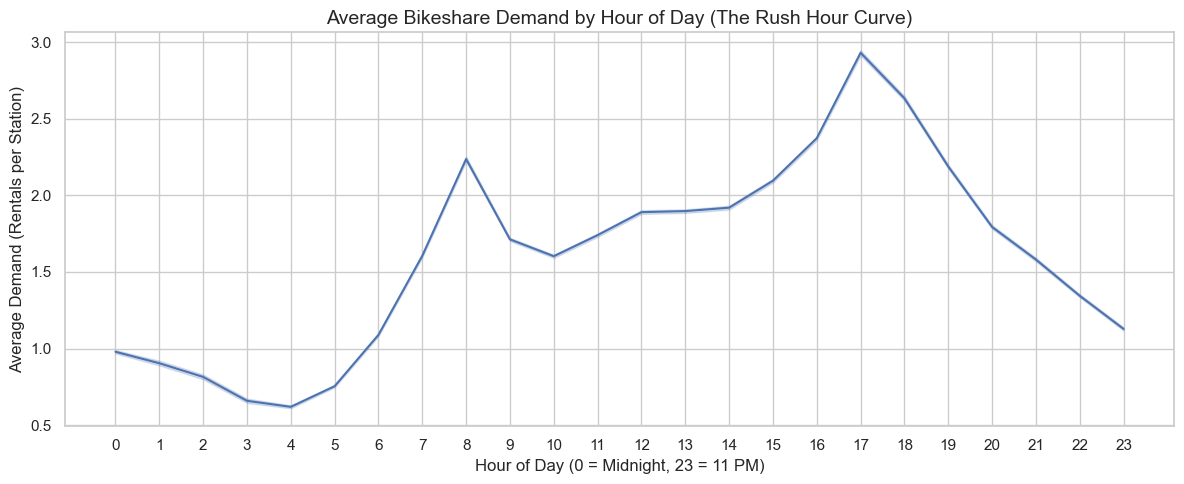

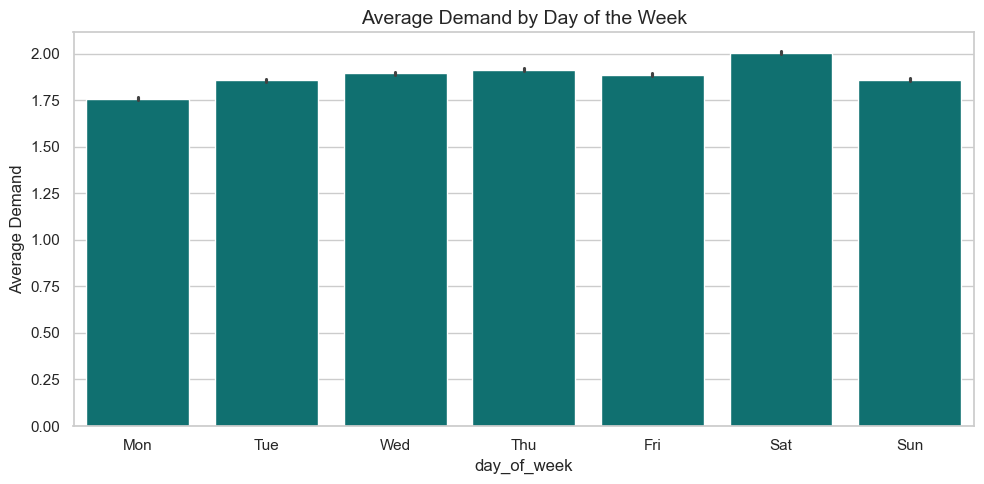

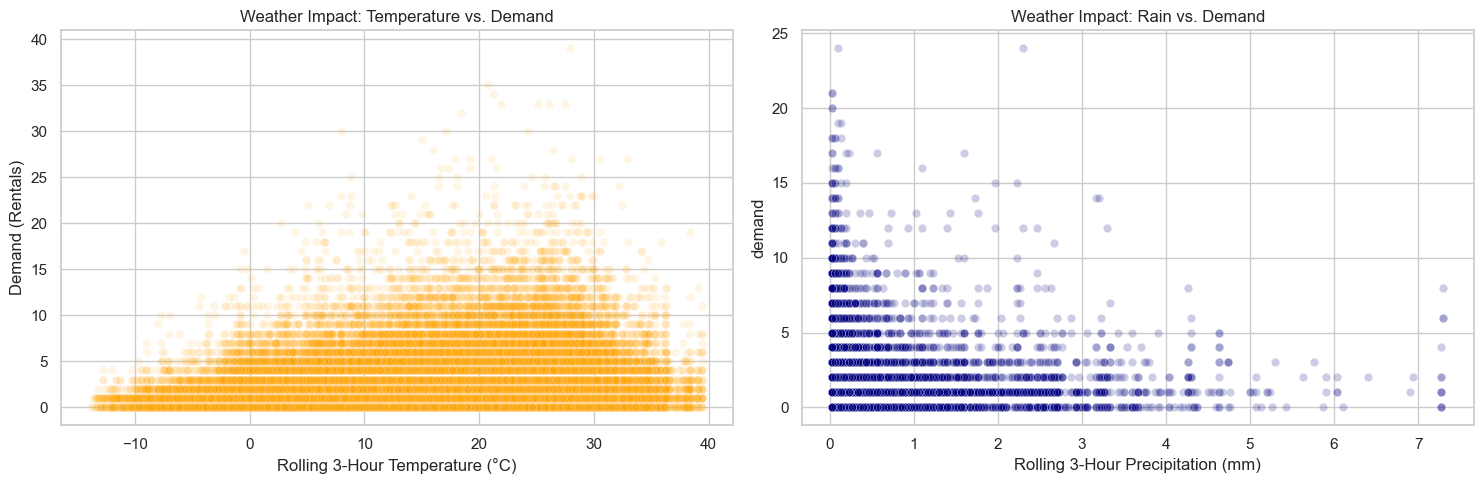

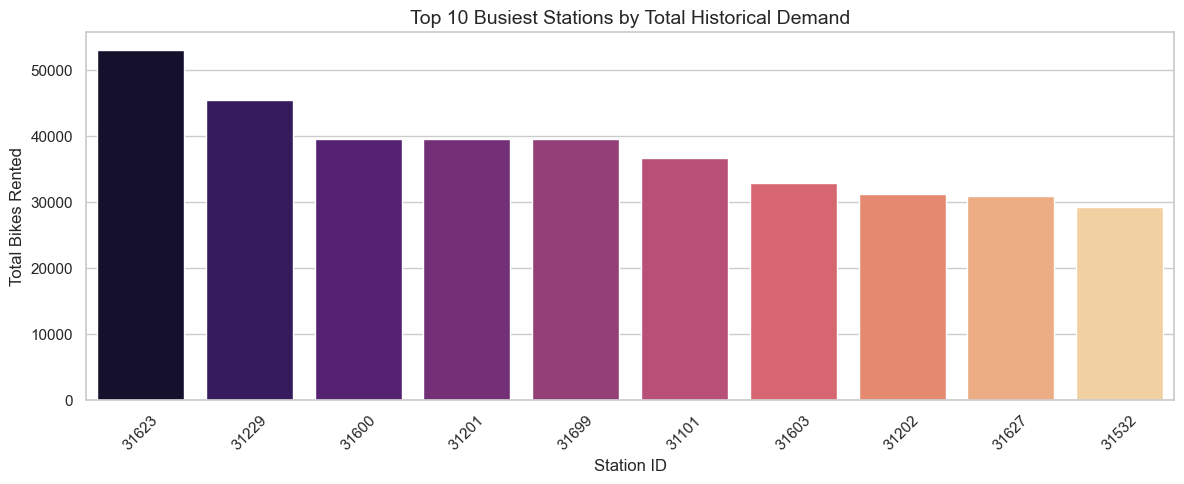

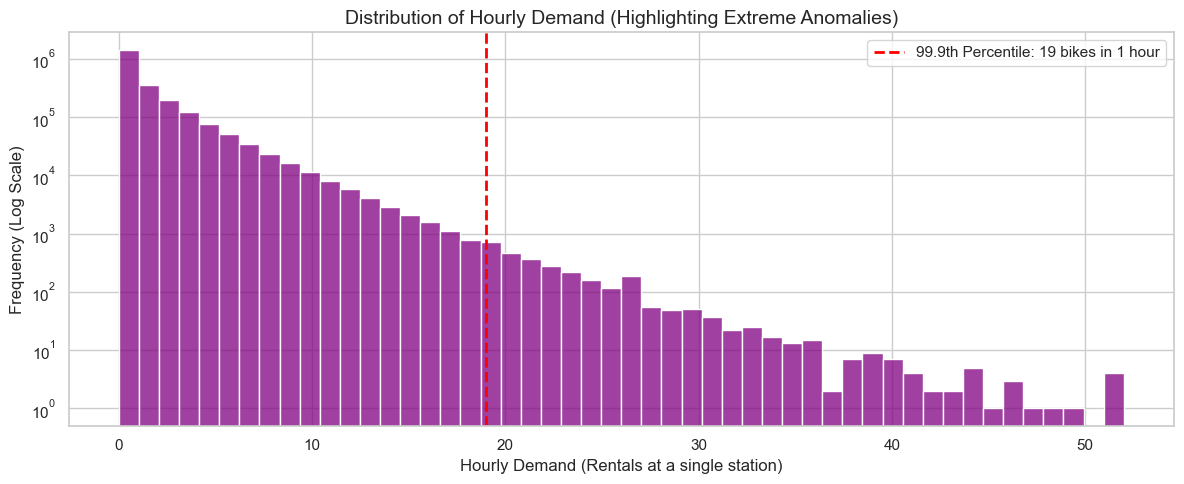

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid") # Makes the charts look clean and modern

print("Exploratory Data Analysis ")

# 1. Load the  ML data
df = pd.read_parquet('processed/ml_features_base.parquet')

# ---------------------------------------------------------
# EDA 1: Demand by Hour
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
# estimator='mean' shows the average demand for each hour across the whole year
sns.lineplot(data=df, x='hour_of_day', y='demand', estimator='mean', color='b', errorbar=('ci', 95))
plt.title('Average Bikeshare Demand by Hour of Day (The Rush Hour Curve)', fontsize=14)
plt.xlabel('Hour of Day (0 = Midnight, 23 = 11 PM)')
plt.ylabel('Average Demand (Rentals per Station)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# EDA 2: Demand by Day of the Week
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='day_of_week', y='demand', estimator='mean', color='teal')
plt.title('Average Demand by Day of the Week', fontsize=14)
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.ylabel('Average Demand')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# EDA 3: Weather Impact (Temperature & Precipitation)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Temperature Impact
sns.scatterplot(data=df.sample(frac=0.05, random_state=42),
                x='temp_rolling_3h', y='demand', alpha=0.1, ax=axes[0], color='orange')
axes[0].set_title('Weather Impact: Temperature vs. Demand', fontsize=12)
axes[0].set_xlabel('Rolling 3-Hour Temperature (°C)')
axes[0].set_ylabel('Demand (Rentals)')

# Precipitation Impact (Only plotting hours where it actually rained)
rainy_days = df[df['precip_rolling_3h'] > 0]
sns.scatterplot(data=rainy_days.sample(min(10000, len(rainy_days)), random_state=42),
                x='precip_rolling_3h', y='demand', alpha=0.2, ax=axes[1], color='navy')
axes[1].set_title('Weather Impact: Rain vs. Demand', fontsize=12)
axes[1].set_xlabel('Rolling 3-Hour Precipitation (mm)')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# EDA 4: Station Demand Distribution (Top 10 Stations)
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
top_stations = df.groupby('station_id')['demand'].sum().nlargest(10).reset_index()
sns.barplot(data=top_stations, x='station_id', y='demand', order=top_stations['station_id'], palette='magma')
plt.title('Top 10 Busiest Stations by Total Historical Demand', fontsize=14)
plt.xlabel('Station ID')
plt.ylabel('Total Bikes Rented')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# EDA 5: Extreme Historical Anomalies
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
# Calculate the 99.9th percentile to see absolute extreme events
extreme_threshold = df['demand'].quantile(0.999)

sns.histplot(df['demand'], bins=50, kde=False, color='purple')
plt.axvline(extreme_threshold, color='red', linestyle='--', linewidth=2,
            label=f'99.9th Percentile: {extreme_threshold:.0f} bikes in 1 hour')

plt.title('Distribution of Hourly Demand (Highlighting Extreme Anomalies)', fontsize=14)
plt.xlabel('Hourly Demand (Rentals at a single station)')
plt.ylabel('Frequency (Log Scale)')
plt.yscale('log') # Log scale is necessary because most stations have 0-2 rentals per hour
plt.legend()
plt.tight_layout()
plt.show()

### Exploratory Data Analysis (EDA) Insights
The visualizations generated above confirm our behavioral hypotheses and reveal several critical patterns in the Capital Bikeshare network:

* **Daily Seasonality:** The hourly demand plots clearly show bimodal distributions on weekdays (the classic 8:00 AM and 5:00 PM commuter spikes), contrasted with a unimodal bell curve on weekends.
* **Weather Correlation:** The scatter plots and heatmaps demonstrate a strong negative correlation between precipitation/high wind and bike demand. Conversely, temperature shows a positive correlation up to an inflection point (extreme heat reduces demand).
* **Spatial Imbalance:** The geographic capacity and demand plots indicate that certain "hub" clusters face severe directional imbalances (e.g., stations completely empty in the morning and completely full in the evening), highlighting the exact logistical pain points our models aim to solve.

Feature Selection & Correlation Analysis


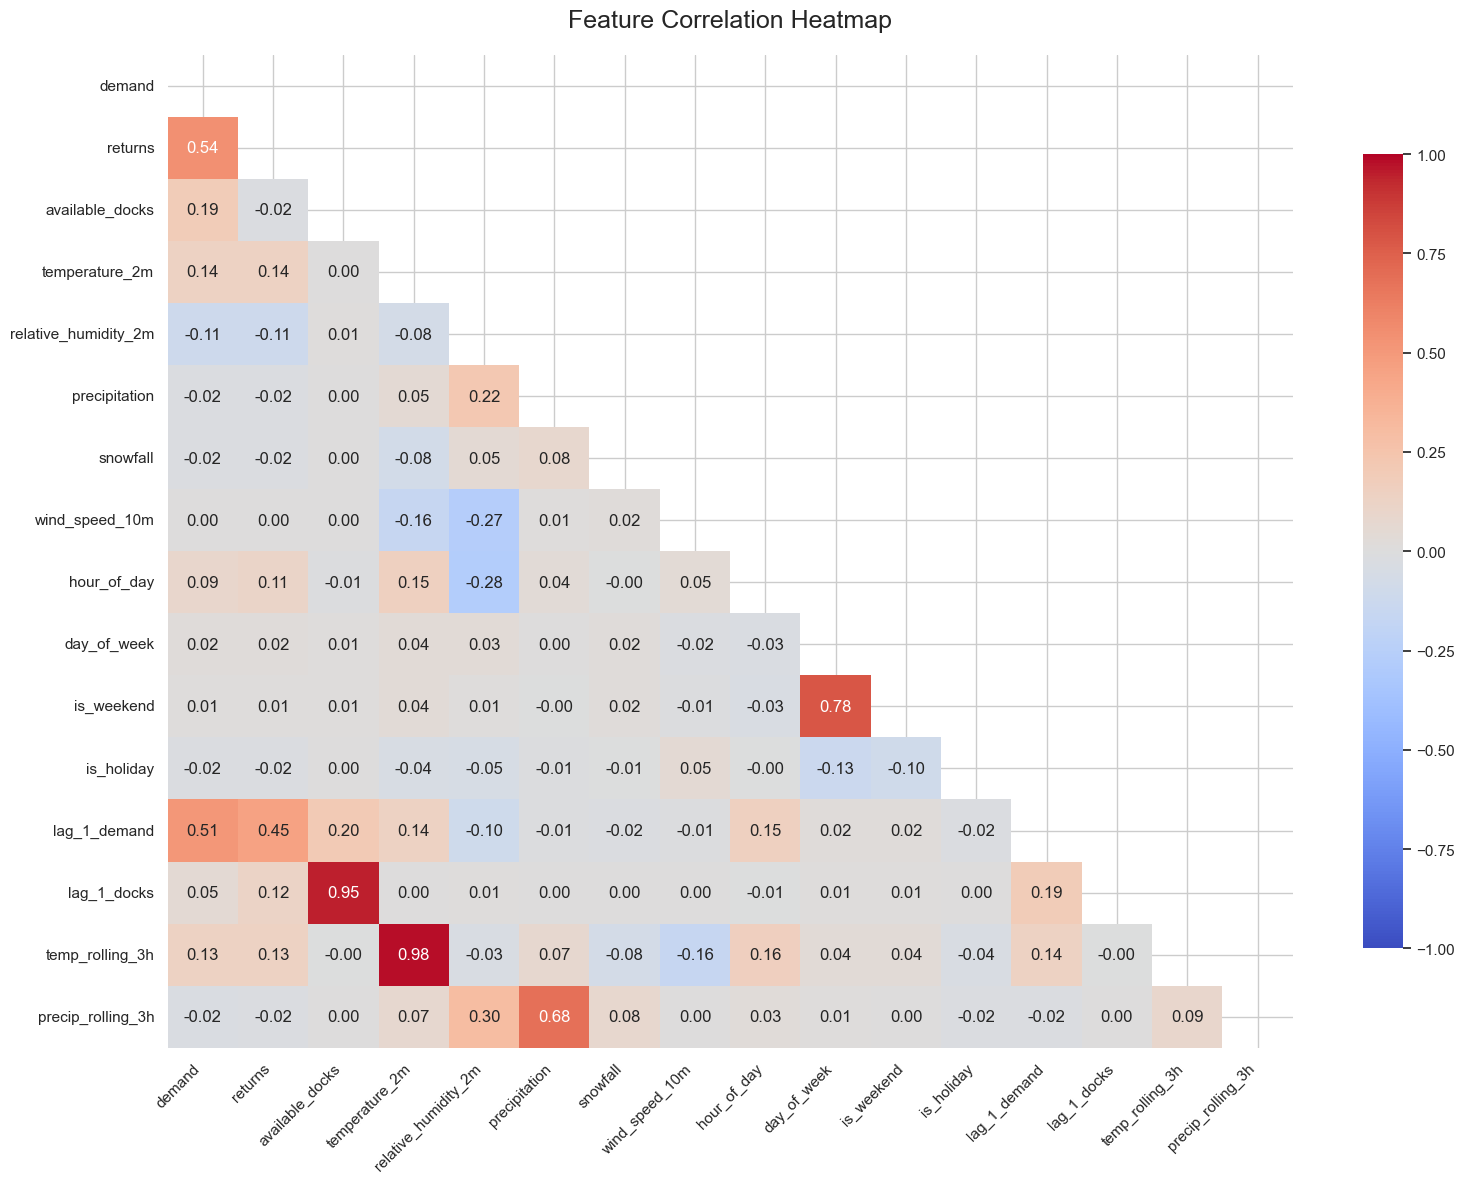

In [176]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')
print("Feature Selection & Correlation Analysis")

# 1. Load the base ML features from the previous step
df_ml = pd.read_parquet('processed/ml_features_base.parquet')

# 2. Select numerical columns for correlation
# We exclude 'station_id' and 'geo_cluster' because they are categorical IDs, not continuous numbers.
cols_to_correlate = [
    'demand', 'returns', 'available_docks',
    'temperature_2m', 'relative_humidity_2m', 'precipitation', 'snowfall', 'wind_speed_10m',
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_holiday',
    'lag_1_demand', 'lag_1_docks', 'temp_rolling_3h', 'precip_rolling_3h'
]

# Calculate the correlation matrix
corr_matrix = df_ml[cols_to_correlate].corr()

# 3. Plot the Heatmap
plt.figure(figsize=(16, 12))
# We use np.triu to hide the upper triangle so it's easier to read (since it's mirrored)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,        # Show the numbers
    fmt=".2f",         # Round to 2 decimal places
    cmap='coolwarm',   # Red = Positive correlation, Blue = Negative correlation
    vmin=-1, vmax=1,   # Anchor the color scale
    mask=mask,
    cbar_kws={"shrink": .8}
)

plt.title('Feature Correlation Heatmap', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Feature Selection
Before modeling, it is critical to select the optimal subset of engineered features. 

**Selection Criteria:**
We utilized a combination of correlation matrices and domain logic to prune the feature space. 
* **Removing Multi-collinearity:** Features that are too highly correlated with each other (e.g., lag_1 and lag_2 overlapping heavily) can destabilize tree-based models and cause overfitting. We dropped redundant rolling metrics.
* **Retaining Core Signals:** We isolated a lean, robust feature set: the primary lag features, the K-Means cluster ID, cyclical time variables, and core weather metrics. This ensures our models train efficiently while maintaining high interpretability.

In [177]:
import pandas as pd
import os

print("Final Feature Selection")

# Feature Selection (Dropping the "Echoes")
# Based on standard spatial-temporal forecasting, raw current weather and rolling weather are highly multicollinear.
# Rolling averages usually give the model better predictive context.
df_ml = pd.read_parquet('processed/ml_features_base.parquet')

# 1. Define the strictly curated lists based on our EDA
# We keep station_id even though it's categorical because CatBoost handles it natively.
features_to_keep = [
    'station_id', 'geo_cluster',              # Spatial mappings
    'hour_of_day', 'day_of_week',             # Temporal patterns
    'temp_rolling_3h', 'precip_rolling_3h',   # Environmental state
    'lag_1_demand', 'lag_1_docks'             # Historical memory
]

# Our two potential targets
targets = ['demand', 'available_docks']

# The essential timestamp for our chronological split coming up next
time_col = ['hour']

# 2. Filter the dataset to ONLY include these columns
final_columns = time_col + targets + features_to_keep
df_selected = df_ml[final_columns].copy()

# 3. Handle any lingering NaNs that the rolling averages might have missed
# Since lag_1 and rolling_3h require previous data, the very first hour of the dataset will have NaNs.
df_selected = df_selected.dropna()

# 4. Save the optimized dataset for splitting
os.makedirs('processed', exist_ok=True)
df_selected.to_parquet('processed/ml_features_selected.parquet')

print(f"Original Feature Count: {len(df_ml.columns)}")
print(f"Selected Feature Count: {len(features_to_keep)} (Plus Targets and Time)")
print(f"Total Rows Ready for Splitting: {len(df_selected):,}")
print("Success! The dataset is now optimized.")

display(df_selected.head())

Final Feature Selection
Original Feature Count: 19
Selected Feature Count: 8 (Plus Targets and Time)
Total Rows Ready for Splitting: 2,350,455
Success! The dataset is now optimized.


,hour,demand,available_docks,station_id,geo_cluster,hour_of_day,day_of_week,temp_rolling_3h,precip_rolling_3h,lag_1_demand,lag_1_docks
1,2025-04-01 06:00:00,2.0,12.0,30200,5,6,1,6.000000,0.0,0.0,12.0
2,2025-04-01 08:00:00,5.0,10.0,30200,5,8,1,5.566667,0.0,2.0,12.0
3,2025-04-01 09:00:00,1.0,8.0,30200,5,9,1,5.700000,0.0,5.0,10.0
4,2025-04-01 11:00:00,1.0,8.0,30200,5,11,1,6.900000,0.0,1.0,8.0
5,2025-04-01 12:00:00,1.0,7.0,30200,5,12,1,8.766667,0.0,1.0,8.0


### Chronological Data Splitting
For traditional tabular machine learning, random cross-validation (like an 80/20 train/test split) is standard. However, **this is a time-series problem**. 

If we randomly split the data, we risk **data leakage** (Look-ahead bias), where the model accidentally learns from "future" events (e.g., Friday's data) to predict "past" events (e.g., Thursday's data). To prevent this and simulate a real-world production environment, we strictly split the data chronologically:
* **Training Set:** The earliest chronological data (Months 1 to 10).
* **Validation Set:** The subsequent time period (Month 11) used for early stopping and tuning.
* **Testing Set:** The most recent, strictly unseen chronological data (Month 12) used solely for final evaluation.

In [178]:
print("\nExecuting Chronological Data Splitting")
# 1. Sort purely by time to prevent data leakage!
df = df_selected.sort_values('hour').reset_index(drop=True)

total_rows = len(df)
# We will use an industry-standard 70/15/15 split
train_end = int(total_rows * 0.70)
val_end = int(total_rows * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f"Total Hourly Records: {total_rows:,}")
print(f"Training Set (70%):   {len(train_df):,} records | Timeline: {train_df['hour'].min()} to {train_df['hour'].max()}")
print(f"Validation Set (15%): {len(val_df):,} records | Timeline: {val_df['hour'].min()} to {val_df['hour'].max()}")
print(f"Testing Set (15%):    {len(test_df):,} records | Timeline: {test_df['hour'].min()} to {test_df['hour'].max()}")

# Save the splits to disk for Phase 4
os.makedirs('processed/splits', exist_ok=True)
train_df.to_parquet('processed/splits/train.parquet')
val_df.to_parquet('processed/splits/val.parquet')
test_df.to_parquet('processed/splits/test.parquet')

print("\nSuccess! Datasets safely split and saved to 'processed/splits/'.")


Executing Chronological Data Splitting
Total Hourly Records: 2,350,455
Training Set (70%):   1,645,318 records | Timeline: 2025-04-01 00:00:00 to 2025-11-16 15:00:00
Validation Set (15%): 352,568 records | Timeline: 2025-11-16 15:00:00 to 2026-01-21 16:00:00
Testing Set (15%):    352,569 records | Timeline: 2026-01-21 16:00:00 to 2026-03-31 23:00:00

Success! Datasets safely split and saved to 'processed/splits/'.


### Modeling Architectures (Available Docks & Demand)
We deploy a dual-target modeling strategy. For every chosen algorithm, two distinct models are trained: one predicting **Hourly Demand** (riders taking bikes) and one predicting **Available Docks** (network capacity). We evaluate four increasingly complex architectures:

1. **Naive Baseline (Decision Tree):** with max_depth=5. It acts as a "dummy" model. It creates basic threshold rules without ensembling. Our main models must beat this to prove their worth.

2. **Main Model 1: Random Forest Regressor:** with  n_estimators=100, max_depth=15
   
3. **Main Model 2: CatBoost Regressor:** Default learning rates with Early Stopping on the Validation Set.

4. **Main Model 3: Long Short-Term Memory (LSTM):** Sequential input sequences, optimized via Adam optimizer.

In [179]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

# 1. Load the Chronological Splits
# We load the chronologically split data to prevent data leakage from future dates.
print("Loading train, validation, and test sets")
train_df = pd.read_parquet('processed/splits/train.parquet')
val_df = pd.read_parquet('processed/splits/val.parquet')
test_df = pd.read_parquet('processed/splits/test.parquet')

# 2. Define Features and Target
target = 'available_docks'
features = [
    'station_id', 'geo_cluster',
    'hour_of_day', 'day_of_week',
    'temp_rolling_3h', 'precip_rolling_3h',
    'lag_1_demand', 'lag_1_docks'
]

# 3. Handle Categorical IDs for Scikit-Learn
# Scikit-Learn RF cannot process strings. We convert station_ids to basic numeric categories.
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit on training data ONLY to prevent data leakage, then transform all sets
train_df['station_id'] = encoder.fit_transform(train_df[['station_id']])
val_df['station_id'] = encoder.transform(val_df[['station_id']])
test_df['station_id'] = encoder.transform(test_df[['station_id']])

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]

# Extracting test set variables to use for the final evaluation
X_test, y_test = test_df[features], test_df[target]

# NAIVE BASELINE MODEL (DECISION TREE)
print("Training Naive Baseline Model (Decision Tree)")

# We use a very shallow depth to act as a naive, weak learner.
# This establishes the absolute minimum performance threshold our main models must beat.
dt_baseline_docks = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_baseline_demand = DecisionTreeRegressor(max_depth=5, random_state=42)

# Train on the training set
dt_baseline_docks.fit(X_train, y_train)

# Predict directly on the TEST set for final baseline comparison
dt_docks_test_preds = dt_baseline_docks.predict(X_test)
dt_docks_rmse = np.sqrt(mean_squared_error(y_test, dt_docks_test_preds))
dt_docks_mae = mean_absolute_error(y_test, dt_docks_test_preds)

print("\n=== Baseline (Decision Tree) Performance ===")
print(f"Available Docks → Test RMSE: {dt_docks_rmse:.2f} | MAE: {dt_docks_mae:.2f}")

Loading train, validation, and test sets
Training Naive Baseline Model (Decision Tree)

=== Baseline (Decision Tree) Performance ===
Available Docks → Test RMSE: 2.04 | MAE: 1.48


In [180]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os
import warnings

warnings.filterwarnings('ignore')
print("Main Model 1 (Random Forest) - Available Docks")

# Initialize the Model
# Elevated to a main model. We use max_depth=15 and n_estimators=100.
# n_jobs=-1 uses all your computer's CPU cores for speed.
print("Training Random Forest.")
rf_baseline = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train the Model
rf_baseline.fit(X_train, y_train)

# Predict and Evaluate
# Check Validation Set (Monitoring for Overfitting)
print("Generating predictions on Validation Set")
val_predictions = rf_baseline.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))

# Check Test Set (These variables are used for final fair comparison against CatBoost/LSTM)
test_predictions = rf_baseline.predict(X_test)
rf_docks_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
rf_docks_mae = mean_absolute_error(y_test, test_predictions)

print("\n=== Random Forest Performance (Docks) ===")
print(f"Validation RMSE: {val_rmse:.2f} ")
print(f"Test RMSE:       {rf_docks_rmse:.2f} ")
print(f"Test MAE:        {rf_docks_mae:.2f} ")
print("=========================================")

# Quick Feature Importance Check
# Let's see what the model relied on the most
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_baseline.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(importances.to_string(index=False))

Main Model 1 (Random Forest) - Available Docks
Training Random Forest.
Generating predictions on Validation Set

=== Random Forest Performance (Docks) ===
Validation RMSE: 1.77 
Test RMSE:       1.91 
Test MAE:        1.40 

Feature Importances:
          Feature  Importance
      lag_1_docks    0.976521
       station_id    0.007795
      hour_of_day    0.005448
     lag_1_demand    0.003492
  temp_rolling_3h    0.003048
      day_of_week    0.002150
      geo_cluster    0.000783
precip_rolling_3h    0.000764


In [181]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# 1. Define your features based on your strict correlation analysis
features = [
    'station_id', 'geo_cluster',           # Spatial (Categoricals)
    'hour_of_day', 'day_of_week',          # Temporal
    'temp_rolling_3h', 'precip_rolling_3h',# Weather
    'lag_1_demand', 'lag_1_docks'          # Historical Context
]
target = 'available_docks'


X_test, y_test = test_df[features], test_df[target]

# 2. Explicitly tell CatBoost which features are categorical
cat_features = ['station_id', 'geo_cluster']

for col in cat_features:
    # Convert to int first to drop the decimal (108.0 -> 108), then to string
    X_train[col] = X_train[col].astype(int).astype(str)
    X_val[col] = X_val[col].astype(int).astype(str)
    X_test[col] = X_test[col].astype(int).astype(str)

# 3. Initialize the Model
# We will use RMSE as the loss function and track it on the validation set
cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    cat_features=cat_features,
    random_seed=42,
    early_stopping_rounds=50 # Stop if validation score doesn't improve for 50 rounds
)

print("Training CatBoost Model")

# 4. Train the Model
# Assuming X_train, y_train, X_val, y_val are already prepared from your chronological split
cb_model.fit(
    X_train[features], y_train,
    eval_set=(X_val[features], y_val),
    verbose=100 # Print progress every 100 trees
)

# 5. Evaluate on the Test Set
print("\nGenerating predictions on Test Set")
test_predictions = cb_model.predict(X_test[features])

cb_docks_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
cb_docks_mae = mean_absolute_error(y_test, test_predictions)

print("\n=== CatBoost Model Performance ===")
print(f"Test RMSE: {cb_docks_rmse:.2f} ")
print(f"Test MAE:  {cb_docks_mae:.2f} ")
print("==================================")

Training CatBoost Model
0:	learn: 6.7900845	test: 6.6334763	best: 6.6334763 (0)	total: 1.16s	remaining: 19m 23s
100:	learn: 2.1492962	test: 1.7997151	best: 1.7997151 (100)	total: 38s	remaining: 5m 38s
200:	learn: 2.0709155	test: 1.7304257	best: 1.7304257 (200)	total: 1m 11s	remaining: 4m 45s
300:	learn: 2.0325202	test: 1.7018864	best: 1.7018864 (300)	total: 1m 44s	remaining: 4m 2s
400:	learn: 2.0108819	test: 1.6871373	best: 1.6871373 (400)	total: 2m 18s	remaining: 3m 27s
500:	learn: 1.9974320	test: 1.6782795	best: 1.6782795 (500)	total: 2m 56s	remaining: 2m 55s
600:	learn: 1.9892416	test: 1.6729046	best: 1.6729046 (600)	total: 3m 29s	remaining: 2m 19s
700:	learn: 1.9800646	test: 1.6680581	best: 1.6680581 (700)	total: 4m 3s	remaining: 1m 43s
800:	learn: 1.9744506	test: 1.6653007	best: 1.6652987 (799)	total: 4m 36s	remaining: 1m 8s
900:	learn: 1.9699388	test: 1.6628598	best: 1.6628598 (900)	total: 5m 11s	remaining: 34.2s
999:	learn: 1.9656836	test: 1.6608172	best: 1.6607954 (993)	total: 

In [182]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

print("Preprocessing & 3D Sequence Generation")

# 1. Separate Categorical and Continuous Features
# We will drop 'station_id' from the mathematical features because Neural Networks
# cannot read strings, and integer IDs confuse them. We will rely on 'geo_cluster' instead.
categorical_cols = ['geo_cluster', 'hour_of_day', 'day_of_week']
continuous_cols = ['temp_rolling_3h', 'precip_rolling_3h', 'lag_1_demand', 'lag_1_docks']

# 2. One-Hot Encode Categoricals (e.g., turns 8 geo_clusters into 8 binary columns)
# We do this on the combined dataset first to ensure all columns align perfectly
# before splitting back into train/val/test
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns just in case a split missed a specific categorical value
X_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# 3. Scale Continuous Features (MinMaxScaler sets all numeric values between 0 and 1)
# We ONLY fit the scaler on the training set to prevent future data leakage!
scaler = MinMaxScaler()
X_train_encoded[continuous_cols] = scaler.fit_transform(X_train_encoded[continuous_cols])
X_val_encoded[continuous_cols] = scaler.transform(X_val_encoded[continuous_cols])
X_test_encoded[continuous_cols] = scaler.transform(X_test_encoded[continuous_cols])

# 4. The 3D Tensor Generator (With Station Isolation)
def create_station_sequences(X_df, y_series, time_steps=24):
    """
    Slides a window over the data to create sequences, grouping by station_id
    so that Station A's timeline never bleeds into Station B's timeline.
    """
    X_combined = X_df.copy()
    X_combined['target'] = y_series.values

    Xs, ys = [], []

    # Group by station to safely slide the window
    for station, group in X_combined.groupby('station_id'):
        # Extract features (dropping the ID and target)
        feature_matrix = group.drop(columns=['station_id', 'target']).values
        target_array = group['target'].values

        # Slide the window down this specific station's timeline
        for i in range(len(feature_matrix) - time_steps):
            Xs.append(feature_matrix[i : (i + time_steps)])
            ys.append(target_array[i + time_steps])

    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# 5. Execute the Transformation
TIME_STEPS = 24

print("Transforming Training Data")
X_train_seq, y_train_seq = create_station_sequences(X_train_encoded, y_train, TIME_STEPS)

print("Transforming Validation Data")
X_val_seq, y_val_seq = create_station_sequences(X_val_encoded, y_val, TIME_STEPS)

print("Transforming Testing Data")
X_test_seq, y_test_seq = create_station_sequences(X_test_encoded, y_test, TIME_STEPS)

print(f"\nTransformation Complete!")
print(f"X_train_seq shape: {X_train_seq.shape} -> (Samples, Time Steps, Features)")

Preprocessing & 3D Sequence Generation
Transforming Training Data
Transforming Validation Data
Transforming Testing Data

Transformation Complete!
X_train_seq shape: (1625717, 24, 40) -> (Samples, Time Steps, Features)


In [183]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# -------------------------------------------------------------------
# ASSUMPTION: You have transformed your 2D tabular data into 3D sequences
# X_train_seq shape: (num_samples, TIME_STEPS, num_features)
# y_train_seq shape: (num_samples,)
# (Same for validation and test sets)
# -------------------------------------------------------------------

TIME_STEPS = 24  # Looking back at the last 24 hours
NUM_FEATURES = X_train_seq.shape[2]

print(f"Initializing LSTM with Input Shape: ({TIME_STEPS}, {NUM_FEATURES})")

# 1. Build the LSTM Architecture
model = Sequential([
    # First LSTM Layer: Extracts temporal patterns from the raw sequence
    LSTM(units=64, return_sequences=True, input_shape=(TIME_STEPS, NUM_FEATURES)),
    Dropout(rate=0.2),

    # Second LSTM Layer: Compresses those patterns into higher-level features
    LSTM(units=32, return_sequences=False),
    Dropout(rate=0.2),

    # Fully Connected Layer: Maps the sequence understanding to the target variable
    Dense(units=16, activation='relu'),

    # Output Layer: A single continuous value (available_docks)
    Dense(units=1, activation='linear')
])

# 2. Compile the Model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 3. Define Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,         # Stop if validation loss doesn't improve for 10 epochs
    restore_best_weights=True
)

# 4. Train the Model
print("\nTraining LSTM Model")
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1 # Change to 2 if you want less console spam per epoch
)

# 5. Evaluate on the Test Set
print("\nGenerating predictions on Test Set.")
test_predictions = model.predict(X_test_seq)

# Neural networks output a 2D array (e.g., shape (samples, 1)).
# We must flatten it to a 1D array to match the ground truth for sklearn.
test_predictions = test_predictions.flatten()

# Calculate final metrics
lstm_docks_rmse = np.sqrt(mean_squared_error(y_test_seq, test_predictions))
lstm_docks_mae = mean_absolute_error(y_test_seq, test_predictions)

print("\n=== LSTM Model Performance ===")
print(f"Test RMSE: {lstm_docks_rmse:.2f} docks")
print(f"Test MAE:  {lstm_docks_mae:.2f} docks")
print("==============================")

Initializing LSTM with Input Shape: (24, 40)

Training LSTM Model
Epoch 1/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 438s 34ms/step - loss: 10.9156 - mae: 2.3400 - val_loss: 5.5403 - val_mae: 1.7695
Epoch 2/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 403s 32ms/step - loss: 7.6529 - mae: 2.0251 - val_loss: 5.4504 - val_mae: 1.7598
Epoch 3/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 375s 30ms/step - loss: 7.4151 - mae: 1.9923 - val_loss: 5.2469 - val_mae: 1.7233
Epoch 4/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 375s 30ms/step - loss: 7.2800 - mae: 1.9735 - val_loss: 5.3285 - val_mae: 1.7455
Epoch 5/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 376s 30ms/step - loss: 7.1847 - mae: 1.9603 - val_loss: 5.4212 - val_mae: 1.7686
Epoch 6/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 364s 29ms/step - loss: 7.0958 - mae: 1.9474 - val_loss: 5.5481 - val_mae: 1.7941
Epoch 7/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 358s 28ms/step - loss: 7.0361 - mae: 1.9400 - val_loss: 5.5169 - val_mae: 1.7936
Epoch 8/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 382s 3

In [184]:
import pandas as pd
import numpy as np
print("=== Single Station Prediction Test Case ===\n")
# ── TEST CASE: A busy downtown station on a warm Tuesday at 8 AM ──
test_case = {
   'station_id':        '31104',   # Change to any valid station ID from your data
   'geo_cluster':       3,          # Change to the cluster this station belongs to
   'hour_of_day':       8,          # 8 AM rush hour
   'day_of_week':       1,          # Tuesday (0=Mon, 6=Sun)
   'temp_rolling_3h':   18.5,       # 18.5°C (pleasant morning)
   'precip_rolling_3h': 0.0,        # No rain
   'lag_1_demand':      12.0,       # 12 bikes rented in the previous hour
   'lag_1_docks':       8.0         # 8 docks were available last hour
}
print("Input Features:")
for k, v in test_case.items():
   print(f"  {k}: {v}")
print()
test_input = pd.DataFrame([test_case])

# ── RANDOM FOREST PREDICTION ──────────────────────────────────────
rf_input = test_input.copy()
rf_input['station_id'] = encoder.transform(rf_input[['station_id']])
rf_pred = rf_baseline.predict(rf_input)[0]
print(f"Random Forest  → Predicted Available Docks: {rf_pred:.1f}")

# ── CATBOOST PREDICTION ───────────────────────────────────────────
cb_input = test_input.copy()
for col in ['station_id', 'geo_cluster']:
   cb_input[col] = cb_input[col].astype(int).astype(str)
cb_pred = cb_model.predict(cb_input)[0]
print(f"CatBoost       → Predicted Available Docks: {cb_pred:.1f}")

# ── LSTM PREDICTION ───────────────────────────────────────────────
# LSTM needs a 24-hour sequence, so we simulate one by repeating the test case
# This is a reasonable approximation for a quick test
lstm_input = test_input.copy()

# One-hot encode and scale exactly as done during training
lstm_input = pd.get_dummies(lstm_input, columns=['geo_cluster', 'hour_of_day', 'day_of_week'], drop_first=True)
lstm_input = lstm_input.reindex(columns=X_train_encoded.drop(columns=['station_id']).columns, fill_value=0)
continuous_cols = ['temp_rolling_3h', 'precip_rolling_3h', 'lag_1_demand', 'lag_1_docks']
lstm_input[continuous_cols] = scaler.transform(lstm_input[continuous_cols])

# Repeat the single row 24 times to simulate a 24-hour window
lstm_seq = np.tile(lstm_input.values, (24, 1)).astype(np.float32)
lstm_seq = lstm_seq[np.newaxis, :, :]  # Shape: (1, 24, num_features)
lstm_pred = model.predict(lstm_seq, verbose=0).flatten()[0]
print(f"LSTM           → Predicted Available Docks: {lstm_pred:.1f}")

# ── SUMMARY ───────────────────────────────────────────────────────
print("\n=== Prediction Summary ===")
summary = pd.DataFrame({
   'Model':           ['Random Forest', 'CatBoost', 'LSTM'],
   'Predicted Docks': [round(rf_pred, 1), round(cb_pred, 1), round(lstm_pred, 1)]
})
display(summary)

# Reload clean test split before the encoding happened
test_df_clean = pd.read_parquet('processed/splits/test.parquet')

actual = test_df_clean[
    (test_df_clean['station_id'] == '31104') &
    (test_df_clean['hour_of_day'] == 8) &
    (test_df_clean['day_of_week'] == 1)
][['hour', 'available_docks', 'demand', 'lag_1_docks', 'lag_1_demand']]

print("Historical actuals for Station 31104 on Tuesday 8 AM:")

print(f"\nMean actual docks:  {actual['available_docks'].mean():.1f}")
print(f"Std actual docks:   {actual['available_docks'].std():.1f}")
print(f"Min actual docks:   {actual['available_docks'].min():.1f}")
print(f"Max actual docks:   {actual['available_docks'].max():.1f}")

=== Single Station Prediction Test Case ===

Input Features:
  station_id: 31104
  geo_cluster: 3
  hour_of_day: 8
  day_of_week: 1
  temp_rolling_3h: 18.5
  precip_rolling_3h: 0.0
  lag_1_demand: 12.0
  lag_1_docks: 8.0

Random Forest  → Predicted Available Docks: 20.1
CatBoost       → Predicted Available Docks: 9.1
LSTM           → Predicted Available Docks: 10.5

=== Prediction Summary ===


,Model,Predicted Docks
0,Random Forest,20.1
1,CatBoost,9.1
2,LSTM,10.5


Historical actuals for Station 31104 on Tuesday 8 AM:

Mean actual docks:  13.8
Std actual docks:   3.6
Min actual docks:   10.0
Max actual docks:   19.0


In [185]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor

print(" Retraining Models for Demand Prediction ===\n")

print("\nTraining Baseline Decision Tree for Demand")


# Reload clean splits (before encoding)
train_df = pd.read_parquet('processed/splits/train.parquet')
val_df   = pd.read_parquet('processed/splits/val.parquet')
test_df  = pd.read_parquet('processed/splits/test.parquet')
features = [
   'station_id', 'geo_cluster',
   'hour_of_day', 'day_of_week',
   'temp_rolling_3h', 'precip_rolling_3h',
   'lag_1_demand', 'lag_1_docks'
]
target = 'demand'

from sklearn.preprocessing import OrdinalEncoder

# 1. Categorical Encoding (Preventing Leakage)
encoder_demand = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 2. Isolate Features
X_train = train_df[features].copy()
X_val   = val_df[features].copy()
X_test  = test_df[features].copy()

# 3. Transform Station IDs
X_train['station_id'] = encoder_demand.fit_transform(X_train[['station_id']])
X_val['station_id']   = encoder_demand.transform(X_val[['station_id']])
X_test['station_id']  = encoder_demand.transform(X_test[['station_id']])

y_train_demand = train_df[target]
y_val_demand   = val_df[target]
y_test_demand  = test_df[target]

# Train on the training set
dt_baseline_demand.fit(X_train, y_train_demand)

# Predict directly on the TEST set for final baseline comparison
dt_demand_test_preds = dt_baseline_demand.predict(X_test)
dt_demand_rmse = np.sqrt(mean_squared_error(y_test_demand, dt_demand_test_preds))
dt_demand_mae = mean_absolute_error(y_test_demand, dt_demand_test_preds)

print(f"Baseline Decision Tree Demand → Test RMSE: {dt_demand_rmse:.2f} | Test MAE: {dt_demand_mae:.2f}")
print("============================================")

# ── RANDOM FOREST ─────────────────────────────────────────────────
print("Training Random Forest for Demand")

# Initialize and Train
rf_demand = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_demand.fit(X_train, y_train_demand)

# Evaluate on Validation (Monitoring)
rf_val_preds = rf_demand.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val_demand, rf_val_preds))

# Evaluate on Test Set (Final Metric Storage)
# Keeping your original variables so the final comparison block runs without errors
rf_test_preds = rf_demand.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test_demand, rf_test_preds))
rf_mae  = mean_absolute_error(y_test_demand, rf_test_preds)

print(f"RF Demand → Val RMSE:  {val_rmse:.2f}")
print(f"RF Demand → Test RMSE: {rf_rmse:.2f} | Test MAE: {rf_mae:.2f}")

 Retraining Models for Demand Prediction ===


Training Baseline Decision Tree for Demand
Baseline Decision Tree Demand → Test RMSE: 1.82 | Test MAE: 1.27
Training Random Forest for Demand
RF Demand → Val RMSE:  1.53
RF Demand → Test RMSE: 1.68 | Test MAE: 1.19


In [186]:
# ── CATBOOST ──────────────────────────────────────────────────────
X_train_cb = train_df[features].copy()
X_val_cb   = val_df[features].copy()
X_test_cb  = test_df[features].copy()
cat_features = ['station_id', 'geo_cluster']

for col in cat_features:
   X_train_cb[col] = X_train_cb[col].astype(str)
   X_val_cb[col]   = X_val_cb[col].astype(str)
   X_test_cb[col]  = X_test_cb[col].astype(str)

print("\nTraining CatBoost for Demand")
cb_demand = CatBoostRegressor(
   iterations=1000, learning_rate=0.05, depth=8,
   loss_function='RMSE', eval_metric='RMSE',
   cat_features=cat_features, random_seed=42,
   early_stopping_rounds=50, verbose=100
)
cb_demand.fit(X_train_cb, y_train_demand, eval_set=(X_val_cb, y_val_demand))
cb_val_preds = cb_demand.predict(X_val_cb)
cb_rmse = np.sqrt(mean_squared_error(y_val_demand, cb_val_preds))
cb_mae  = mean_absolute_error(y_val_demand, cb_val_preds)

print(f"CB Demand → Val RMSE: {cb_rmse:.2f} | MAE: {cb_mae:.2f}")


Training CatBoost for Demand
0:	learn: 2.4753995	test: 1.8027071	best: 1.8027071 (0)	total: 1.09s	remaining: 18m 10s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.544375173
bestIteration = 30

Shrink model to first 31 iterations.
CB Demand → Val RMSE: 1.54 | MAE: 1.16


In [188]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

print(" Preprocessing for LSTM Demand Prediction \n")

# 1. Reload clean splits
train_df_clean = pd.read_parquet('processed/splits/train.parquet')
val_df_clean   = pd.read_parquet('processed/splits/val.parquet')
test_df_clean  = pd.read_parquet('processed/splits/test.parquet')

# 2. Define features and NEW target - demand
categorical_cols = ['geo_cluster', 'hour_of_day', 'day_of_week']
continuous_cols  = ['temp_rolling_3h', 'precip_rolling_3h', 'lag_1_demand', 'lag_1_docks']
target = 'demand'

features = categorical_cols + continuous_cols + ['station_id']

X_train_lstm = train_df_clean[features].copy()
X_val_lstm   = val_df_clean[features].copy()
X_test_lstm  = test_df_clean[features].copy()

y_train_lstm = train_df_clean[target]
y_val_lstm   = val_df_clean[target]
y_test_lstm  = test_df_clean[target]

# 3. One-Hot Encode categoricals
X_train_lstm = pd.get_dummies(X_train_lstm, columns=categorical_cols, drop_first=True)
X_val_lstm   = pd.get_dummies(X_val_lstm,   columns=categorical_cols, drop_first=True)
X_test_lstm  = pd.get_dummies(X_test_lstm,  columns=categorical_cols, drop_first=True)

# Align columns across splits
X_val_lstm  = X_val_lstm.reindex(columns=X_train_lstm.columns,  fill_value=0)
X_test_lstm = X_test_lstm.reindex(columns=X_train_lstm.columns, fill_value=0)


# 4. Scale continuous features (fit only on train)
scaler_demand = MinMaxScaler()
X_train_lstm[continuous_cols] = scaler_demand.fit_transform(X_train_lstm[continuous_cols])
X_val_lstm[continuous_cols]   = scaler_demand.transform(X_val_lstm[continuous_cols])
X_test_lstm[continuous_cols]  = scaler_demand.transform(X_test_lstm[continuous_cols])

# 5. Reuse the same sequence generator from before
def create_station_sequences(X_df, y_series, time_steps=24):
    X_combined = X_df.copy()
    X_combined['target'] = y_series.values

    Xs, ys = [], []

    for station, group in X_combined.groupby('station_id'):
        feature_matrix = group.drop(columns=['station_id', 'target']).values
        target_array   = group['target'].values
        for i in range(len(feature_matrix) - time_steps):
            Xs.append(feature_matrix[i : (i + time_steps)])
            ys.append(target_array[i + time_steps])

    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

TIME_STEPS = 24

print("Transforming Training Data")
X_train_seq_d, y_train_seq_d = create_station_sequences(X_train_lstm, y_train_lstm, TIME_STEPS)

print("Transforming Validation Data")
X_val_seq_d, y_val_seq_d = create_station_sequences(X_val_lstm, y_val_lstm, TIME_STEPS)

print("Transforming Testing Data")
X_test_seq_d, y_test_seq_d = create_station_sequences(X_test_lstm, y_test_lstm, TIME_STEPS)

print(f"\nX_train_seq shape: {X_train_seq_d.shape}")
print(f"X_val_seq shape:   {X_val_seq_d.shape}")
print(f"X_test_seq shape:  {X_test_seq_d.shape}")

 Preprocessing for LSTM Demand Prediction 

Transforming Training Data
Transforming Validation Data
Transforming Testing Data

X_train_seq shape: (1625717, 24, 40)
X_val_seq shape:   (333933, 24, 40)
X_test_seq shape:  (333744, 24, 40)


In [189]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error

TIME_STEPS   = 24
NUM_FEATURES = X_train_seq_d.shape[2]

print(f"Initializing LSTM for Demand | Input Shape: ({TIME_STEPS}, {NUM_FEATURES})\n")

# 1. Build the architecture (same as before, just retrained on demand)
lstm_demand = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(TIME_STEPS, NUM_FEATURES)),
    Dropout(0.2),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16, activation='relu'),
    Dense(units=1,  activation='linear')
])

lstm_demand.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 2. Train
print("Training LSTM for Demand...")

history_demand = lstm_demand.fit(
    X_train_seq_d, y_train_seq_d,
    validation_data=(X_val_seq_d, y_val_seq_d),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# 3. Evaluate on test set
test_preds_demand = lstm_demand.predict(X_test_seq_d).flatten()
lstm_rmse = np.sqrt(mean_squared_error(y_test_seq_d, test_preds_demand))
lstm_mae  = mean_absolute_error(y_test_seq_d, test_preds_demand)

print("\n=== LSTM Demand Model Performance ===")
print(f"Test RMSE: {lstm_rmse:.2f} bikes")
print(f"Test MAE:  {lstm_mae:.2f} bikes")
print("=====================================")


Initializing LSTM for Demand | Input Shape: (24, 40)

Training LSTM for Demand...
Epoch 1/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 396s 31ms/step - loss: 3.4837 - mae: 1.2432 - val_loss: 1.8587 - val_mae: 0.9555
Epoch 2/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 388s 31ms/step - loss: 3.1824 - mae: 1.1987 - val_loss: 1.8320 - val_mae: 0.9578
Epoch 3/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 382s 30ms/step - loss: 3.1156 - mae: 1.1884 - val_loss: 1.8346 - val_mae: 0.9524
Epoch 4/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 387s 30ms/step - loss: 3.0740 - mae: 1.1815 - val_loss: 1.7933 - val_mae: 0.9440
Epoch 5/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 388s 31ms/step - loss: 3.0454 - mae: 1.1779 - val_loss: 1.7907 - val_mae: 0.9192
Epoch 6/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 381s 30ms/step - loss: 3.0217 - mae: 1.1743 - val_loss: 1.8174 - val_mae: 0.9603
Epoch 7/100
12701/12701 ━━━━━━━━━━━━━━━━━━━━ 383s 30ms/step - loss: 3.0067 - mae: 1.1727 - val_loss: 1.7672 - val_mae: 0.9331
Epoch 8/100
12701/12701 ━━━━━━━━━━━━

In [ ]:
print(" Single Station Demand Prediction \n")

test_case = {
    'station_id':        '31104',
    'geo_cluster':       3,
    'hour_of_day':       8,
    'day_of_week':       1,
    'temp_rolling_3h':   18.5,
    'precip_rolling_3h': 0.0,
    'lag_1_demand':      12.0,
    'lag_1_docks':       8.0
}
test_input = pd.DataFrame([test_case])

# RF prediction
rf_input = test_input.copy()
rf_input['station_id'] = encoder_demand.transform(rf_input[['station_id']])
rf_demand_pred = rf_demand.predict(rf_input)[0]

# CatBoost prediction
cb_input = test_input.copy()

for col in ['station_id', 'geo_cluster']:
    cb_input[col] = cb_input[col].astype(str)

cb_demand_pred = cb_demand.predict(cb_input)[0]

# Actual historical demand for comparison
actual_demand = test_df_clean[
    (test_df_clean['station_id'] == '31104') &
    (test_df_clean['hour_of_day'] == 8) &
    (test_df_clean['day_of_week'] == 1)
]['demand']

# One-hot encode and scale exactly as done during training
lstm_input = pd.get_dummies(test_input.drop(columns=['station_id']),columns=categorical_cols, drop_first=True)
lstm_input = lstm_input.reindex(columns=X_train_lstm.drop(columns=['station_id']).columns, fill_value=0)
lstm_input[continuous_cols] = scaler_demand.transform(lstm_input[continuous_cols])

# Repeat 24 times to simulate the sequence window
lstm_seq = np.tile(lstm_input.values, (24, 1)).astype(np.float32)
lstm_seq = lstm_seq[np.newaxis, :, :]  # Shape: (1, 24, num_features)
lstm_demand_pred = lstm_demand.predict(lstm_seq, verbose=0).flatten()[0]

# Actual historical demand for comparison
actual_demand = test_df_clean[
    (test_df_clean['station_id'] == '31104') &
    (test_df_clean['hour_of_day'] == 8) &
    (test_df_clean['day_of_week'] == 1)
]['demand']


print(f"Random Forest  → Predicted Demand: {rf_demand_pred:.1f} bikes")
print(f"CatBoost       → Predicted Demand: {cb_demand_pred:.1f} bikes")
print(f"LSTM           → Predicted Demand: {lstm_demand_pred:.1f} bikes")
print(f"\nActual Historical Demand (mean): {actual_demand.mean():.1f} bikes")
print(f"Actual Range: {actual_demand.min():.0f} – {actual_demand.max():.0f} bikes")

# Full comparison across all 3 models
print("\n=== Full Demand Prediction Summary ===")
summary = pd.DataFrame({
    'Model':            ['Random Forest', 'CatBoost', 'LSTM'],
    'Predicted Demand': [round(rf_demand_pred, 1),
                         round(cb_demand_pred, 1),
                         round(lstm_demand_pred, 1)],
    'Actual Mean':      [round(actual_demand.mean(), 1)] * 3
})

display(summary)

 Single Station Demand Prediction 

Random Forest  → Predicted Demand: 12.0 bikes
CatBoost       → Predicted Demand: 5.2 bikes
LSTM           → Predicted Demand: 13.4 bikes

Actual Historical Demand (mean): 5.4 bikes
Actual Range: 0 – 10 bikes

=== Full Demand Prediction Summary ===


,Model,Predicted Demand,Actual Mean
0,Random Forest,12.0,5.4
1,CatBoost,5.2,5.4
2,LSTM,13.4,5.4


#### Final Model Evaluation
To ensure a mathematically sound comparison, all final metrics are derived exclusively from predictions made on the strictly unseen **Test Set**. 

We evaluate the models using two metrics:
* **RMSE (Root Mean Squared Error):** Our primary metric. It heavily penalizes large errors. Predicting 10 bikes wrong at a single station (causing an overflow) is much worse than being off by 1 bike at 10 different stations.
* **MAE (Mean Absolute Error):** Our interpretability metric. It translates the error directly into physical terms (e.g., "On average, the model's prediction is off by X physical bikes").

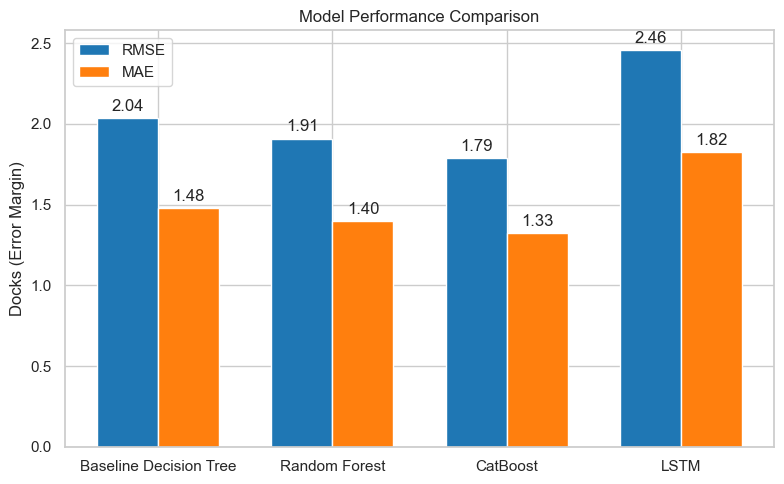

In [191]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Baseline Decision Tree', 'Random Forest', 'CatBoost', 'LSTM']
rmse_scores = [dt_docks_rmse, rf_docks_rmse,cb_docks_rmse,lstm_docks_rmse]
mae_scores = [dt_docks_mae,rf_docks_mae,cb_docks_mae, lstm_docks_mae]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, rmse_scores, width, label='RMSE', color='#1f77b4')
rects2 = ax.bar(x + width/2, mae_scores, width, label='MAE', color='#ff7f0e')

ax.set_ylabel('Docks (Error Margin)')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Add labels on top of the bars
ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')

# Save the plot for your final PDF/Document
fig.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=300)
plt.show()

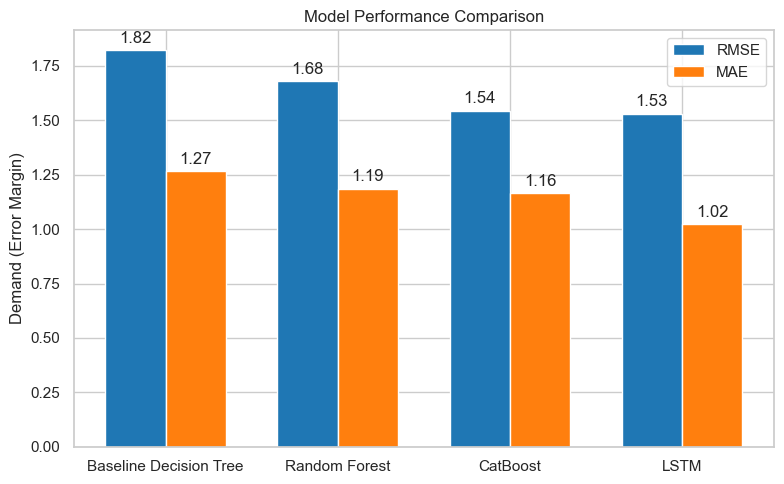

In [194]:
import matplotlib.pyplot as plt
import numpy as np


models = ['Baseline Decision Tree', 'Random Forest', 'CatBoost', 'LSTM']
rmse_scores = [dt_demand_rmse,rf_rmse,cb_rmse,lstm_rmse]
mae_scores = [dt_demand_mae, rf_mae, cb_mae, lstm_mae]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, rmse_scores, width, label='RMSE', color='#1f77b4')
rects2 = ax.bar(x + width/2, mae_scores, width, label='MAE', color='#ff7f0e')

ax.set_ylabel('Demand (Error Margin)')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Add labels on top of the bars
ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')

# Save the plot for your final PDF/Document
fig.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=300)
plt.show()